# AIS lakehouse: Raw data -> Cleaned data in storage -> Query
Store the same ship-movement data (AIS) many different
ways on disk, then ask the same queries, and measure which storage layout answers
fastest without changing the query text.

The data lives in Parquet files on object storage (MinIO/S3), catalogued by Apache Iceberg, and queried with DuckDB + MobilityDuck. For example, when a query asks for "ships near this port last Tuesday", the engine can skip any file (or chunk of a file) whose stored min/max bounds don't overlap the question( pruning). How we arrange the rows into files decides how much can be skipped. Less data read = faster query.

One row = one trajectory segment (a piece of one ship's path). Every layout stores the identical columns (see §1); they differ only in "rows and how they are grouped into files".

### The layouts (how the rows are grouped)
| name | grouped by | note |
|---|---|---|
| **L0** | calendar day | the baseline: just split by day, no further spatial structure |
| **L1** | `hash(mmsi)` | scatter ships into N buckets, no spatial meaning |
| **L2** | 50 km **space tiles** (`spaceSplit`) | cut the map into 50 km squares; each file = one square, in each square there are smaller tiles |
| **L3** | 50 km **space tiles** (`MEST`) | same idea as L2, a different tiling method for smaller box in the square |
| **L4** | hour of day (`timeSplit`) | group by time |
| **LH** | **Hilbert curve** order | a space-filling curve that keeps nearby points nearby |

### Two storage "families" of those layouts
- daily: split by calendar day (so a file = one tile *on one day*). Many small files.
- sorted-compact (L1s, L2s, L3s, L4s, LHs): one file per tile for the
  whole month, but inside each file the rows are sorted by location+time and written in small "row-groups", so the engine can skip row-groups within a file. Few files, yet fine pruning.

### What spatial tiling (L2 / L3) actually looks like

To make the layouts concrete, here is one day of real segment bounding boxes around an alert belt, for the two spatial layouts. The thick black lines are the 50 km
file-tile boundaries (= one Parquet file per 50 km square); the thin blue boxes are the per-segment bounding boxes inside those squares, the little boxes the engine prunes on. The
red rectangle is the alert belt.

- L2 (`spaceSplit`) cuts every trajectory on a regular sub-grid -> uniform boxes.
- L3 (`MEST`) uses adaptive boxes (16 segments per box) -> boxes are smaller where traffic is dense, larger where it's sparse.

So a 50 km tile (one file) is itself filled with many small boxes, that two-level structure
(file = 50 km tile, rows = small boxes) is exactly what makes spatial pruning work.

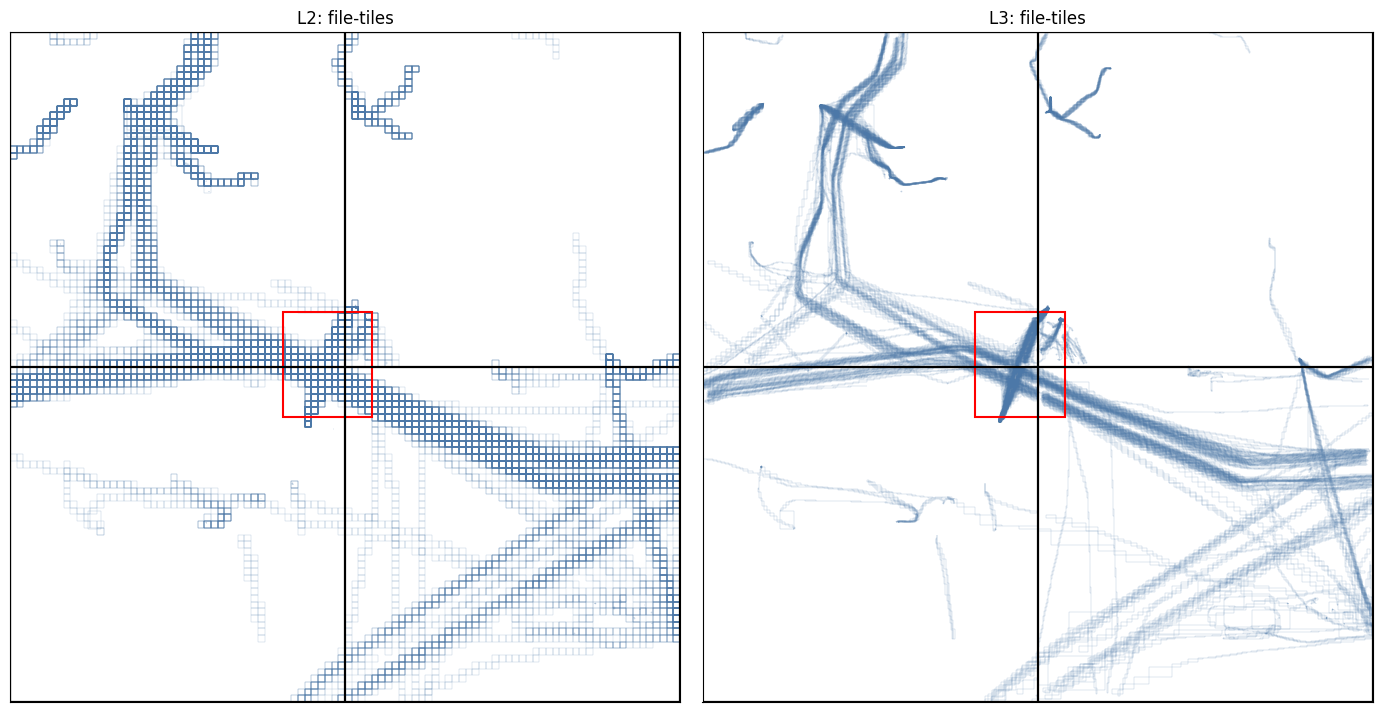

In [17]:
import duckdb as _ddb
import matplotlib.pyplot as _plt, matplotlib.patches as _mp
from lakehouse.query.registry import TRIPS_DEST   # local data/trips OR s3://warehouse/trips

_c = _ddb.connect()
if TRIPS_DEST.startswith("s3://"):     # read trips straight from MinIO
    _c.execute("INSTALL httpfs; LOAD httpfs;")
    _c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
               "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")
_COMPACT = f"{TRIPS_DEST.rstrip('/')}/layout_compact"

X0, X1, Y0, Y1 = 600_000, 700_000, 6_000_000, 6_100_000
TILE = 50_000
BELT = (640730, 6042487, 654100, 6058230)

fig, axes = _plt.subplots(1, 2, figsize=(14, 7))
for ax, (name, src) in zip(axes, [("L2", "L2s"), ("L3", "L3s")]):
    boxes = _c.execute(f"""
        SELECT xmin, ymin, xmax, ymax FROM read_parquet('{_COMPACT}/{src}/**/*.parquet')
        WHERE dt = DATE '2026-01-15'
          AND xmin >= {X0} AND xmax <= {X1} AND ymin >= {Y0} AND ymax <= {Y1}
    """).fetchall()
    for xmin, ymin, xmax, ymax in boxes:                       # thin blue = per-segment boxes
        ax.add_patch(_mp.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, ec="#4c78a8", lw=0.25, alpha=0.5))
    for gx in range(X0, X1 + 1, TILE):                          # thick black = 50 km file-tiles
        ax.axvline(gx, color="k", lw=1.6)
    for gy in range(Y0, Y1 + 1, TILE):
        ax.axhline(gy, color="k", lw=1.6)
    ax.add_patch(_mp.Rectangle((BELT[0], BELT[1]), BELT[2] - BELT[0], BELT[3] - BELT[1],
                               fill=False, ec="red", lw=1.5))   # red = alert belt
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{name}: file-tiles")
_plt.tight_layout()
import os; os.makedirs('figures', exist_ok=True)
fig.savefig('figures/tiling_wide.png', dpi=200, bbox_inches='tight')
_plt.show()


Zoomed in, on a real map: The same boxes for one day, zoomed to the the belt on an OpenStreetMap basemap. Dashed lines = a 50 km file-tile boundary cutting
through the area (the belt straddles a tile corner); red = the alert belt. L2's uniform grid vs L3's lane-hugging adaptive boxes is obvious here.

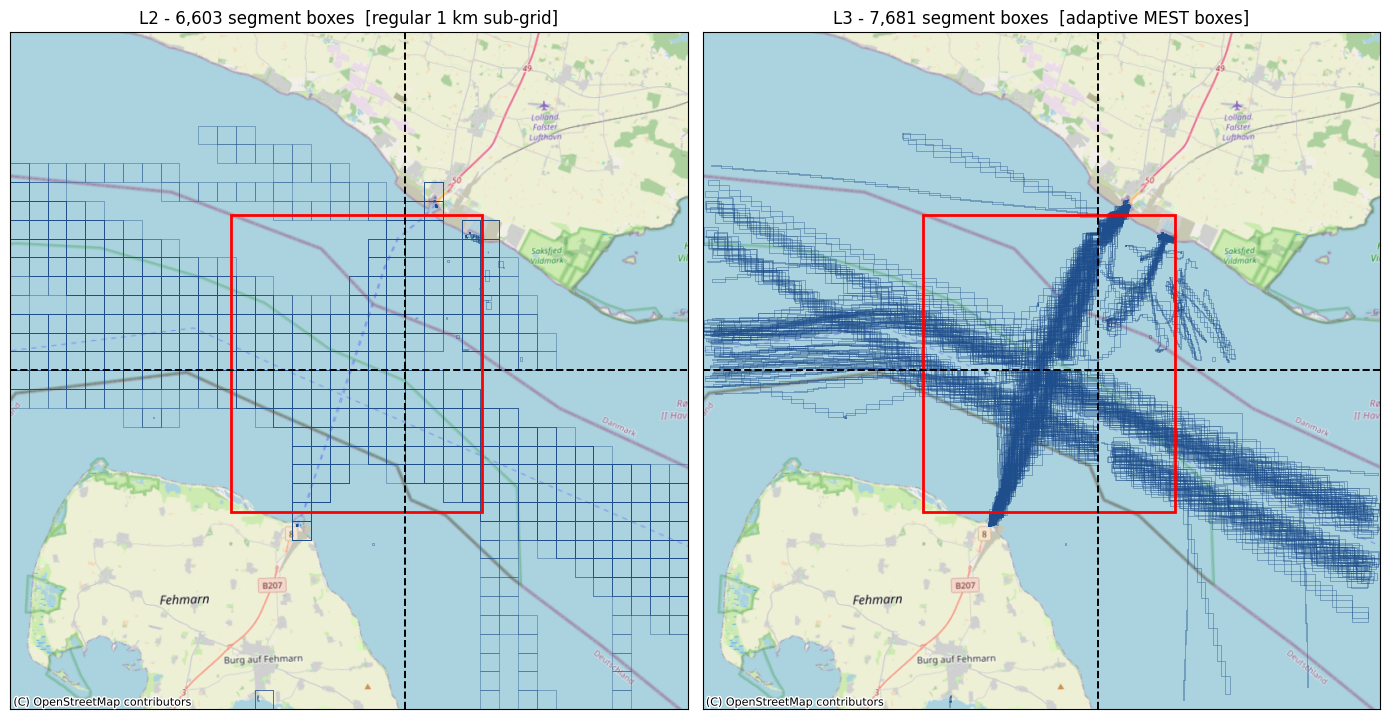

In [18]:
import duckdb as _ddb
import matplotlib.pyplot as _plt, matplotlib.patches as _mp
try:
    import contextily as _cx
except Exception:
    _cx = None
from lakehouse.query.registry import TRIPS_DEST   # local data/trips OR s3://warehouse/trips

_c = _ddb.connect()
if TRIPS_DEST.startswith("s3://"):     # read trips straight from MinIO
    _c.execute("INSTALL httpfs; LOAD httpfs;")
    _c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
               "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")
_COMPACT = f"{TRIPS_DEST.rstrip('/')}/layout_compact"

X0, X1, Y0, Y1 = 629_000, 665_000, 6_032_000, 6_068_000
BELT = (640730, 6042487, 654100, 6058230)

fig, axes = _plt.subplots(1, 2, figsize=(14, 7.5))
for ax, (name, src) in zip(axes, [("L2", "L2s"), ("L3", "L3s")]):
    boxes = _c.execute(f"""
        SELECT xmin, ymin, xmax, ymax FROM read_parquet('{_COMPACT}/{src}/**/*.parquet')
        WHERE dt = DATE '2026-01-15'
          AND xmin >= {X0} AND xmax <= {X1} AND ymin >= {Y0} AND ymax <= {Y1}
    """).fetchall()
    for xmin, ymin, xmax, ymax in boxes:                       # per-segment boxes
        ax.add_patch(_mp.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, ec="#1f4e8c", lw=0.4, alpha=0.7))
    ax.axvline(650_000, color="k", lw=1.4, ls="--")            # the 50 km file-tile boundary
    ax.axhline(6_050_000, color="k", lw=1.4, ls="--")
    ax.add_patch(_mp.Rectangle((BELT[0], BELT[1]), BELT[2] - BELT[0], BELT[3] - BELT[1],
                               fill=False, ec="red", lw=2))     # alert belt
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    tiling = "regular 1 km sub-grid" if name == "L2" else "adaptive MEST boxes"
    ax.set_title(f"{name} - {len(boxes):,} segment boxes  [{tiling}]")
    if _cx is not None:
        try:
            _cx.add_basemap(ax, crs="EPSG:32632", source=_cx.providers.OpenStreetMap.Mapnik)
        except Exception as e:
            print(f"{name}: basemap skipped ({type(e).__name__})")
_plt.tight_layout()
import os; os.makedirs('figures', exist_ok=True)
fig.savefig('figures/tiling_zoom.png', dpi=200, bbox_inches='tight')
_plt.show()


## How it works

Three phases:
(1) build the data files (Parquet in object storage)
(2) register them in the Iceberg catalog
(3) query
All paths are relative to `benchmark/`.

#### Step 1. Build: `../pipeline/run_pipeline.sh` (raw -> all layouts -> Parquet in MinIO)
One script runs these stages in order; each names the command/file that does it and what it writes.
The raw / L0 / daily / compact source layouts stay **local** (build inputs); the final `trips` layers
are written to MinIO (`TRIPS_DEST=s3://warehouse/trips`):

| stage | command / file | output |
|---|---|---|
| ingest | `lakehouse pipeline ingest-range` | `data/raw/aisdk-*.parquet` (raw AIS, local) |
| build L0 | `lakehouse pipeline build-l0` | `data/L0/…` (base trajectory segments, local) |
| daily layouts | `lakehouse pipeline build-layout L1..L4` | `data/layouts_daily/L{1..4}/` (local) |
| compact | `lakehouse pipeline compact-layout` | `data/layout_compact/L{1..4}/` (local) |
| trips schema | [-m lakehouse.process.trips](-m lakehouse.process.trips) | `$TRIPS_DEST/<layout>/` (the 11-col schema, §1) |
| Hilbert | [scripts/build_hilbert.py](scripts/build_hilbert.py) | `$TRIPS_DEST/.../LH` |
| sorted-compact | [scripts/build_sorted_compact.py](scripts/build_sorted_compact.py) | `$TRIPS_DEST/.../{L1s,L2s,L3s,L4s,LHs}` |

#### Step 2. Register in the Iceberg catalog [-m lakehouse.store.publish](-m lakehouse.store.publish)
pyiceberg writes each layout's table metadata
(manifests + the min/max stats used for pruning) into object storage and updates the catalog pointer.
So the data + metadata live on MinIO; the REST catalog is a thin pointer service. Services come from
[iceberg_rest/docker-compose.yml](iceberg_rest/docker-compose.yml) (env in
[deploy/iceberg_rest/env.rest](deploy/iceberg_rest/env.rest)):

```bash
source deploy/iceberg_rest/env.rest
python -m lakehouse.store.publish all        # register every layout as ais.<layout>
```

#### Step 3. Query + measure [-m lakehouse.query.run_iceberg](-m lakehouse.query.run_iceberg) (and this notebook)
The engine asks the REST catalog for the table's current
metadata -> prunes via the min/max stats -> reads only the surviving Parquet from MinIO. It runs every layout x query x time-window from the `.sql` files and writes
[results/iceberg.csv](results/iceberg.csv) (10 queries, one per file in [queries/iceberg/](queries/iceberg/)).
This notebook loads those two CSVs and draws the comparison charts.

## 1. Schema

### The `trips` schema (identical for every layout, only the file grouping differs)
Every layout exposes these same 11 columns, so the query text is identical across layouts. The
**bold** columns are what the engine uses to *prune* (skip data): a file/row-group is read only if
its stored min/max for these columns overlaps the query.
| column | type | role |
|---|---|---|
| `mmsi` | UBIGINT | vessel id |
| `ship_type` | VARCHAR | vessel type |
| `segment_type` | VARCHAR | `in motion` / `stationary` |
| `traj` | BLOB | the trajectory segment (MobilityDB `tgeompoint`, EWKB-encoded) |
| `tmin`, `tmax` | TIMESTAMP | **prunable time bounds** of the segment |
| `xmin, xmax, ymin, ymax` | DOUBLE | **prunable space bounds** (the segment's bounding box) |
| `dt` | DATE | **prunable date** |

In [19]:
import sys, re
import duckdb, pandas as pd, matplotlib.pyplot as plt
from lakehouse.query.registry import MOBILITYDUCK_EXT

def connect():
    """Open DuckDB and ATTACH the Iceberg REST catalog (MinIO warehouse)."""
    c = duckdb.connect(config={"allow_unsigned_extensions": "true"})
    c.execute("INSTALL iceberg; LOAD iceberg;")
    c.execute("INSTALL httpfs; LOAD httpfs;")
    c.execute(f"LOAD '{MOBILITYDUCK_EXT}';")
    c.execute("INSTALL spatial; LOAD spatial;")
    c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
              "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")
    c.execute("ATTACH '' AS lake (TYPE ICEBERG, ENDPOINT 'http://localhost:8181', "
              "AUTHORIZATION_TYPE 'none');")

    c.execute("SET VARIABLE t0   = TIMESTAMP '2026-01-15 08:00:00'")
    c.execute("SET VARIABLE t1   = TIMESTAMP '2026-01-16 08:00:00'")
    c.execute("SET VARIABLE tmid = TIMESTAMP '2026-01-15 20:00:00'")
    c.execute("SET VARIABLE d0   = DATE '2026-01-15'")
    c.execute("SET VARIABLE d1   = DATE '2026-01-16'")
    return c

con = connect()
con.execute("SELECT table_name FROM information_schema.tables "
            "WHERE table_catalog='lake' ORDER BY 1").df()

,table_name
0,L0
1,L0
2,L0
3,L0H
4,L0X
5,L0Z
6,L1_daily
7,L1s
8,L2_daily
9,L2s


## 2. Example: Run a query

In [20]:
# Pick 1 layout
LAYOUT = "L2s"   # sorted-compact spaceSplit 
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM lake.ais.{LAYOUT}")

# both_ports.sql reads its time window from the session variables set in connect() (default = 1 day).
q = open("queries/iceberg/both_ports.sql").read()
print(q)
con.execute(q).df()   

WITH rodby AS (
    SELECT DISTINCT mmsi
    FROM trips
    WHERE xmin <= 651422.0 AND xmax >= 651135.0
      AND ymin <= 6058548.0 AND ymax >= 6058230.0
      AND tmin <= getvariable('t1') AND tmax >= getvariable('t0')
      AND dt BETWEEN getvariable('d0') AND getvariable('d1')
      AND atStbox(tgeompointFromEWKB(traj),
                      stbox(ST_MakeEnvelope(651135.0, 6058230.0, 651422.0, 6058548.0),
                            span(getvariable('t0'), getvariable('t1'), true, true))) IS NOT NULL
),
puttgarden AS (
    SELECT DISTINCT mmsi
    FROM trips
    WHERE xmin <= 644896.0 AND xmax >= 644339.0
      AND ymin <= 6042487.0 AND ymax >= 6042108.0
      AND tmin <= getvariable('t1') AND tmax >= getvariable('t0')
      AND dt BETWEEN getvariable('d0') AND getvariable('d1')
      AND atStbox(tgeompointFromEWKB(traj),
                      stbox(ST_MakeEnvelope(644339.0, 6042108.0, 644896.0, 6042487.0),
                            span(getvariable('t0'), getvariable('t1'), true,

,n_both
0,4


## 3. Visualize result

Above query finds 4 vessels that visited both ferry ports. Plot their tracks 
on an OSM basemap. 

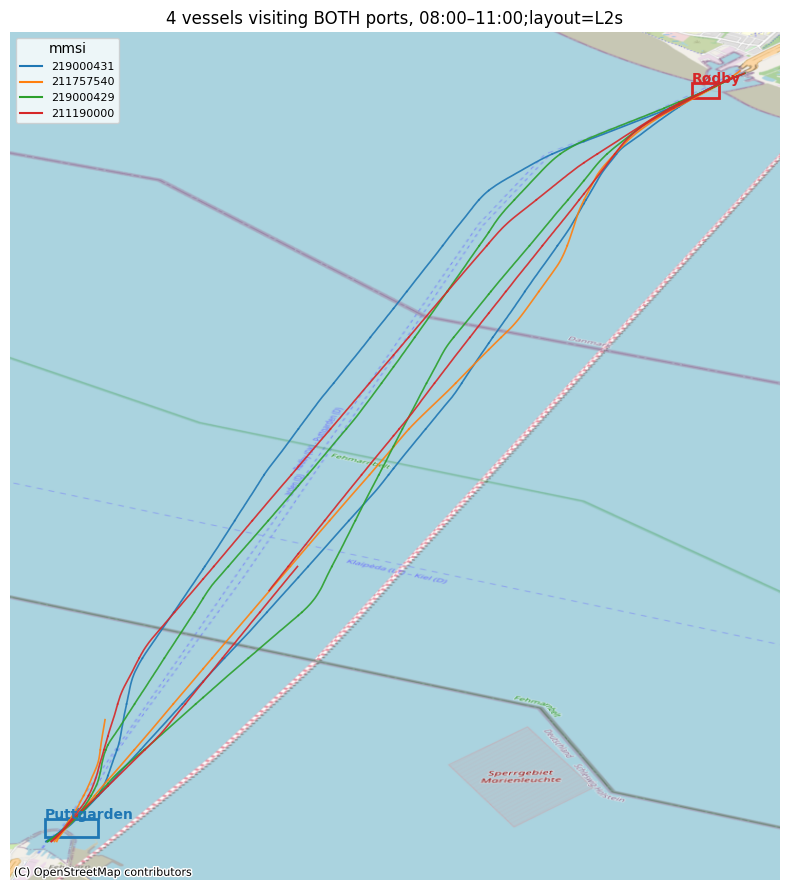

In [21]:
import contextily as cx, matplotlib.patches as mpatches

RODBY = (651135.0, 6058230.0, 651422.0, 6058548.0)
PUTT  = (644339.0, 6042108.0, 644896.0, 6042487.0)
BELT  = (640730.0, 6042487.0, 654100.0, 6058230.0)
W0, W1 = "2026-01-15 08:00:00", "2026-01-15 11:00:00"

both = con.execute(f"""
    WITH ports AS (SELECT ST_MakeEnvelope{RODBY} AS A, ST_MakeEnvelope{PUTT} AS B),
    cand AS (SELECT mmsi, traj FROM trips
             WHERE xmin<={BELT[2]} AND xmax>={BELT[0]} AND ymin<={BELT[3]} AND ymax>={BELT[1]}
               AND dt = DATE '2026-01-15'),
    a AS (SELECT DISTINCT mmsi FROM cand,ports p WHERE eIntersects(tgeompointFromEWKB(traj),p.A)),
    b AS (SELECT DISTINCT mmsi FROM cand,ports p WHERE eIntersects(tgeompointFromEWKB(traj),p.B))
    SELECT mmsi FROM a JOIN b USING(mmsi)
""").df()
mmsis = both.mmsi.tolist()
rows = con.execute(f"""
    SELECT mmsi, ST_AsText(trajectory(atTime(tgeompointFromEWKB(traj),
             span(TIMESTAMP '{W0}', TIMESTAMP '{W1}', true, false)))) AS wkt
    FROM trips
    WHERE mmsi IN ({','.join(map(str,mmsis))})
      AND xmin<={BELT[2]} AND xmax>={BELT[0]} AND ymin<={BELT[3]} AND ymax>={BELT[1]}
      AND tmin < TIMESTAMP '{W1}' AND tmax > TIMESTAMP '{W0}'
""").fetchall()

def segs(wkt):
    out = []
    for g in (re.findall(r"\(([^()]*)\)", wkt) if wkt else []):
        pts = [(float(p.split()[0]), float(p.split()[1])) for p in g.split(",") if len(p.split()) >= 2]
        if pts: out.append(pts)
    return out

fig, ax = plt.subplots(figsize=(8, 9))
colors = plt.cm.tab10.colors
for i, m in enumerate(mmsis):
    for mm, wkt in rows:
        if mm != m: continue
        for s in segs(wkt):
            xs, ys = zip(*s)                                  # already in EPSG:32632 metres
            ax.plot(xs, ys, color=colors[i % 10], lw=1.2, alpha=0.9)
    ax.plot([], [], color=colors[i % 10], label=str(m))
for box, name, c in [(RODBY, "Rødby", "tab:red"), (PUTT, "Puttgarden", "tab:blue")]:
    ax.add_patch(mpatches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                    fill=False, ec=c, lw=2))
    ax.annotate(name, (box[0], box[3]), color=c, fontsize=10, fontweight="bold")
try:
    cx.add_basemap(ax, crs="EPSG:32632", source=cx.providers.OpenStreetMap.Mapnik)
except Exception as e:
    print("basemap skipped (no network?):", e)
ax.set_title(f"{len(mmsis)} vessels visiting BOTH ports, 08:00-11:00;layout={LAYOUT}")
ax.set_axis_off(); ax.legend(title="mmsi", fontsize=8); plt.tight_layout(); plt.show()

## 4. Compare runtime across layouts

This is the core of the notebook: load the two result CSVs (written by
[-m lakehouse.query.run_iceberg](-m lakehouse.query.run_iceberg)) and draw the comparison charts.

- x-axis = selectivity = the query's time-window width(`hour`, `day`, `week`). A wider window asks for more data, so it's a "less selective" (harder) query. 
- The daily family and the sorted-compact family are drawn on separate figures as they're different storage strategies.

To (re)generate the CSVs:
```bash
source deploy/iceberg_rest/env.rest
python -m lakehouse.query.run_iceberg --sels hour,day,week   # -> results/iceberg.csv
```


### 4a. Per-query runtime (all queries)

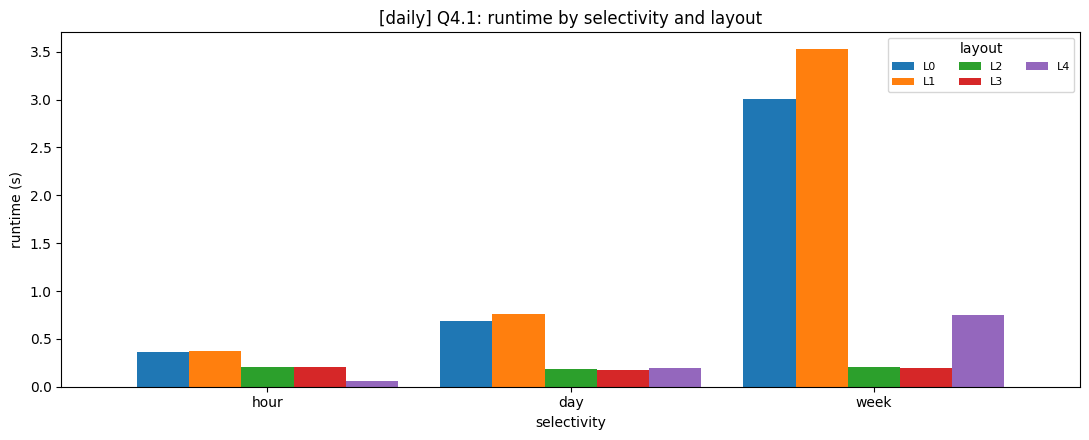

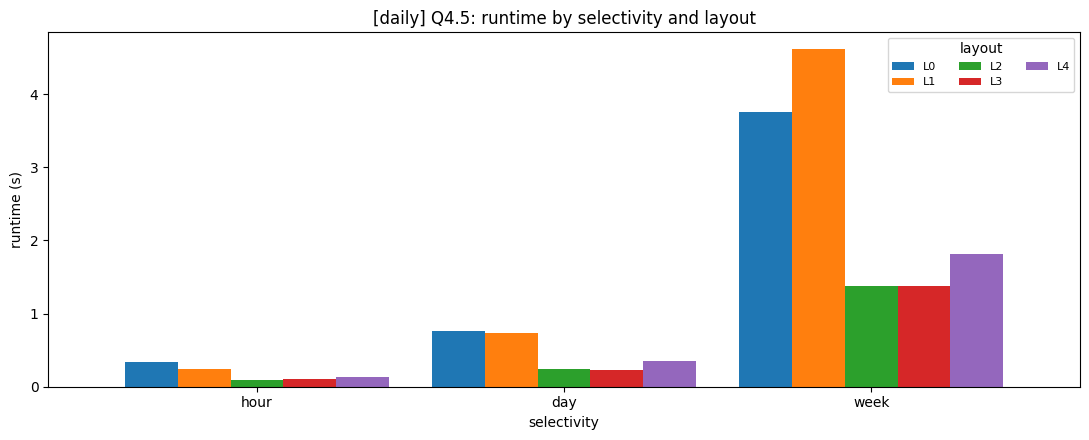

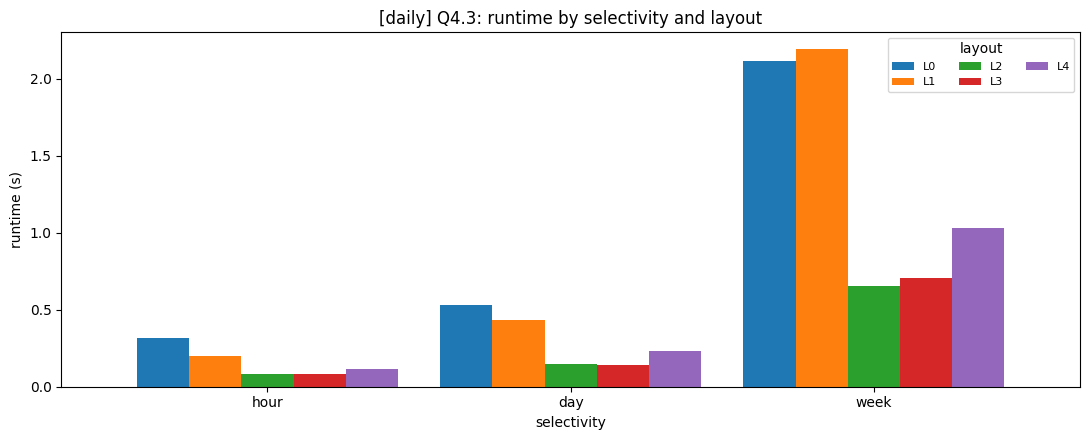

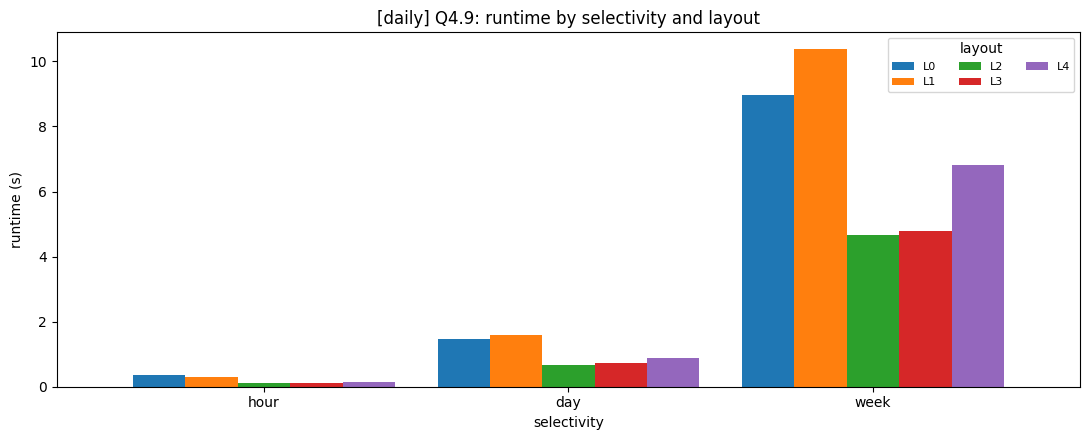

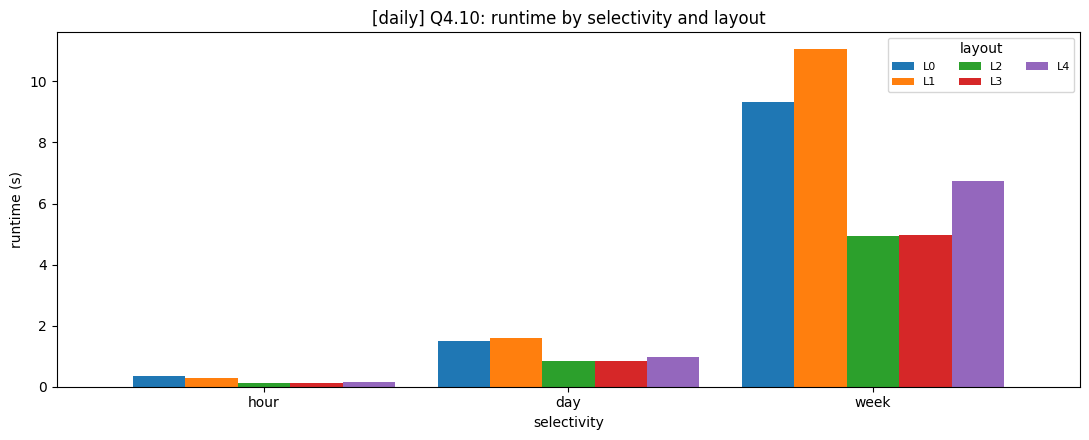

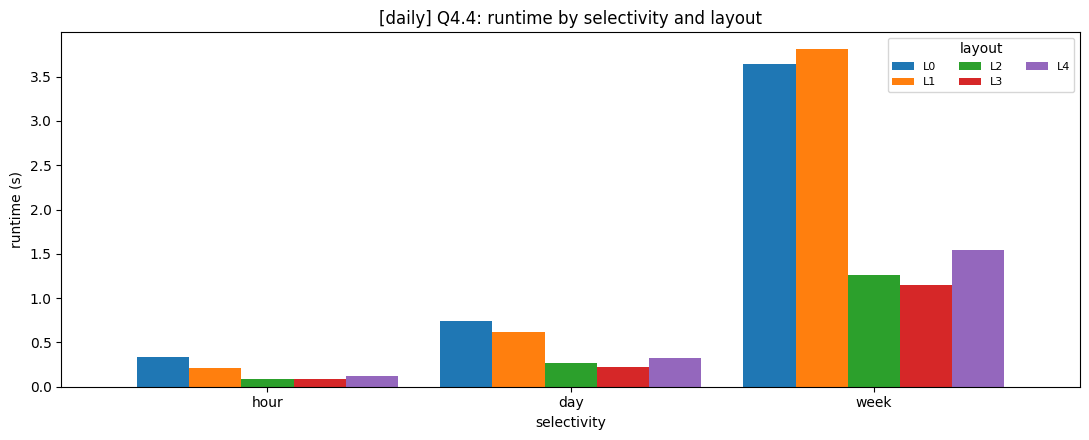

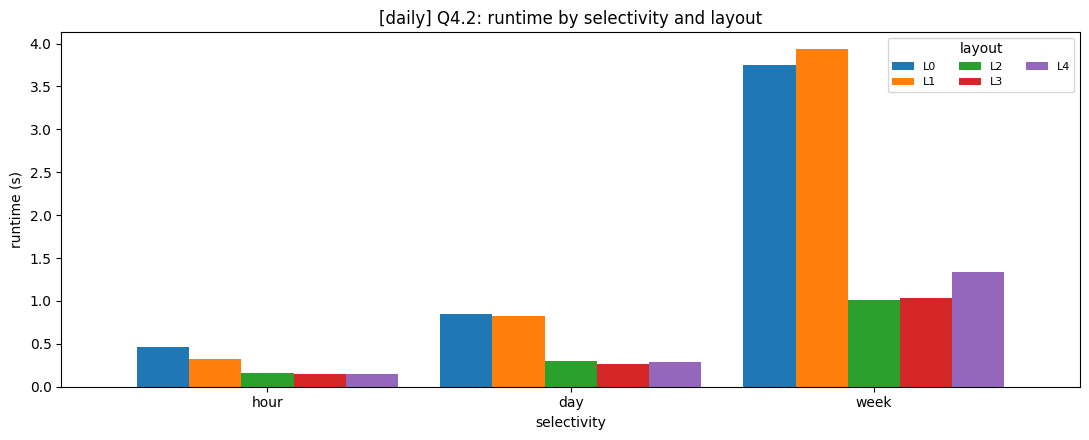

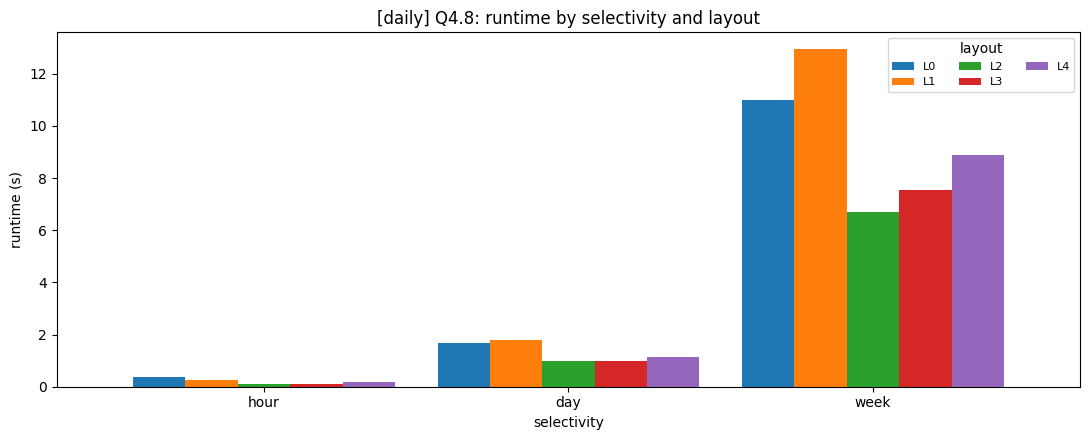

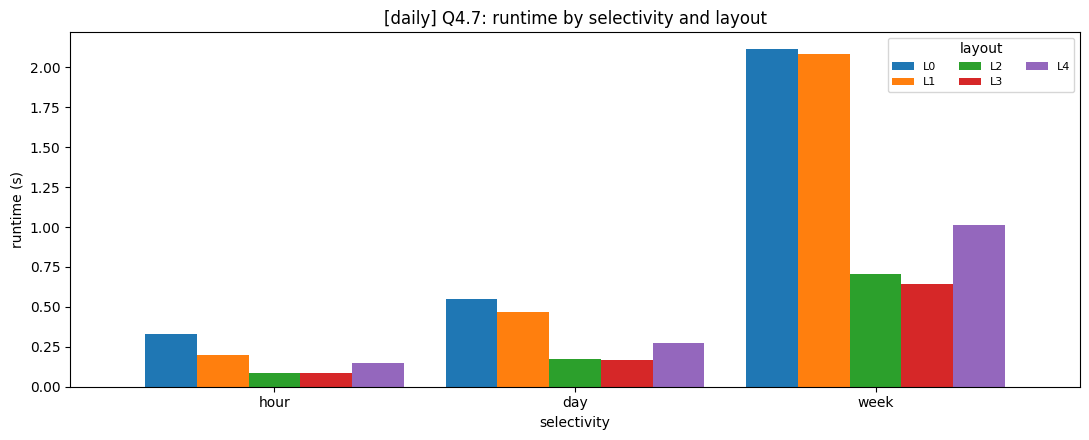

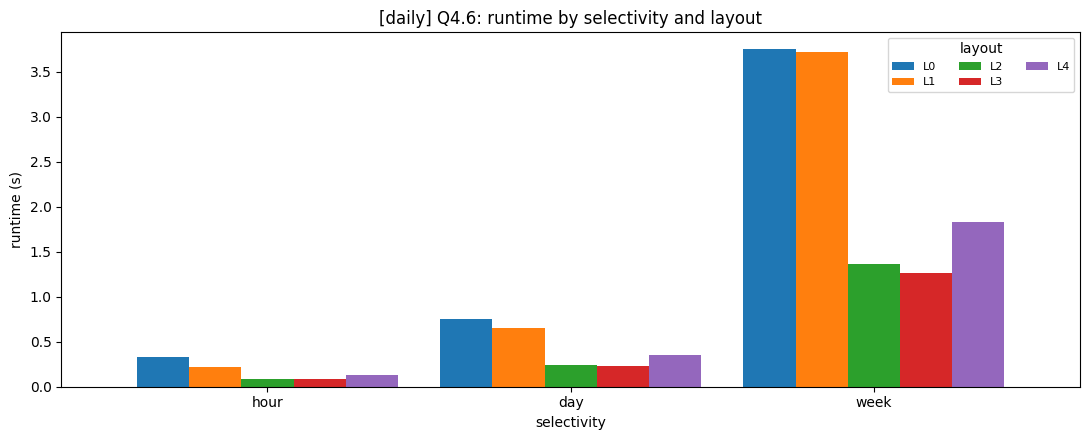

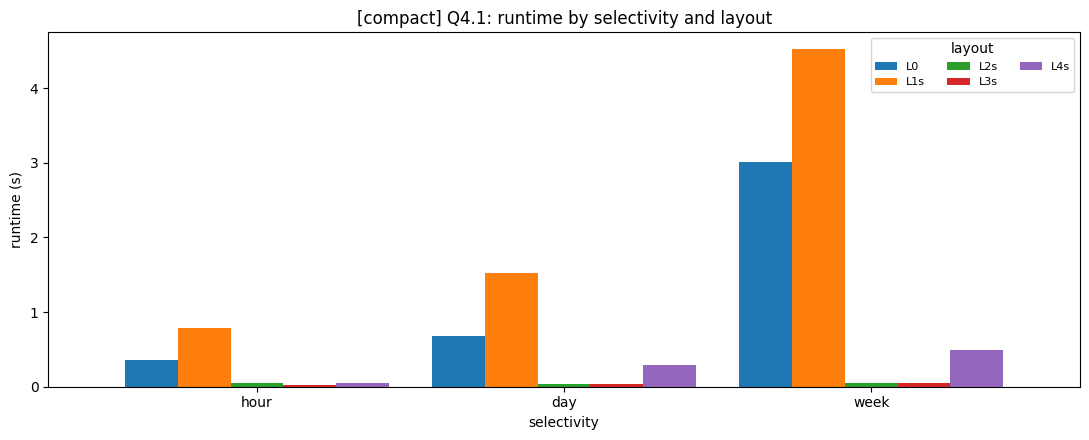

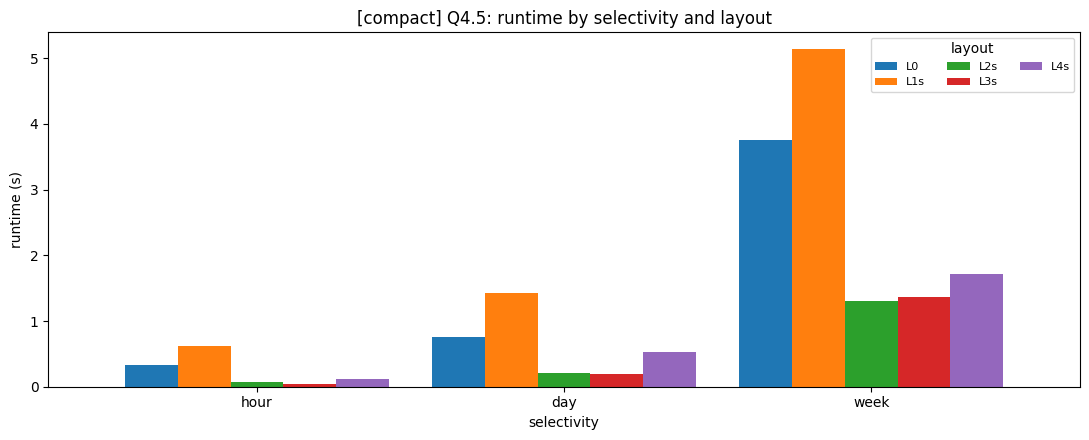

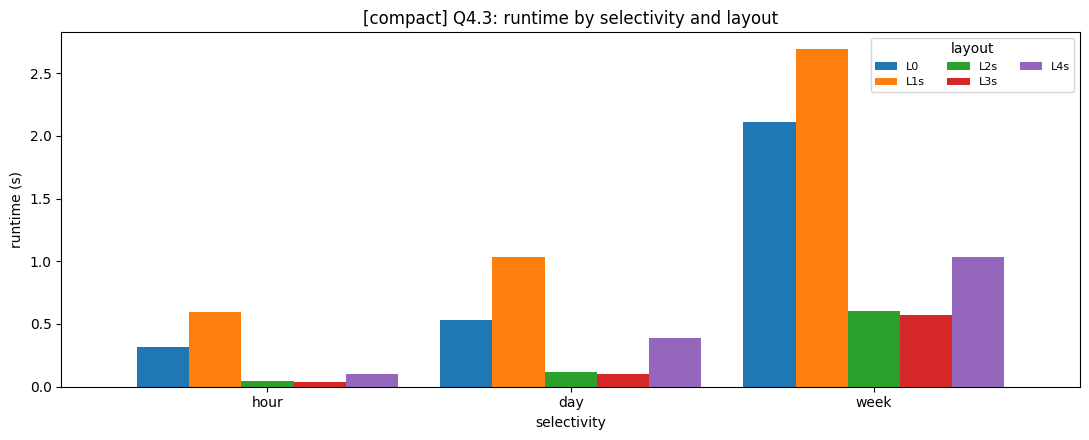

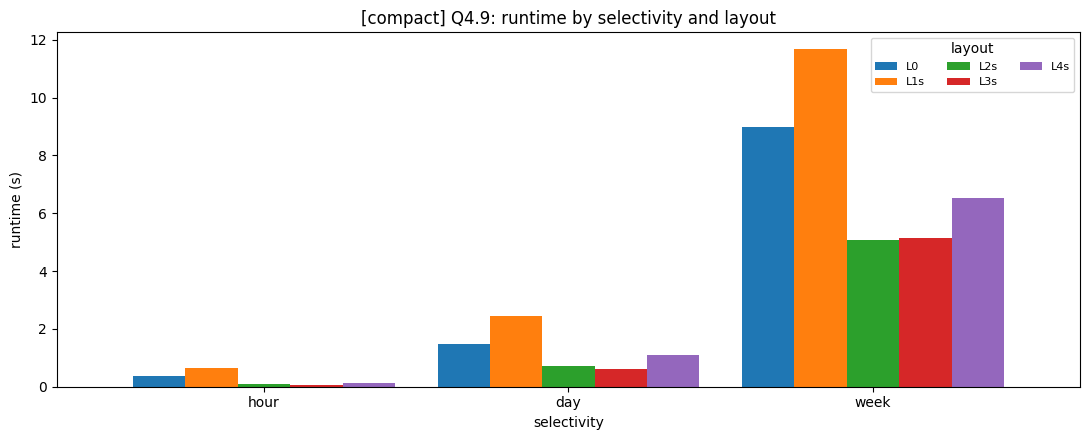

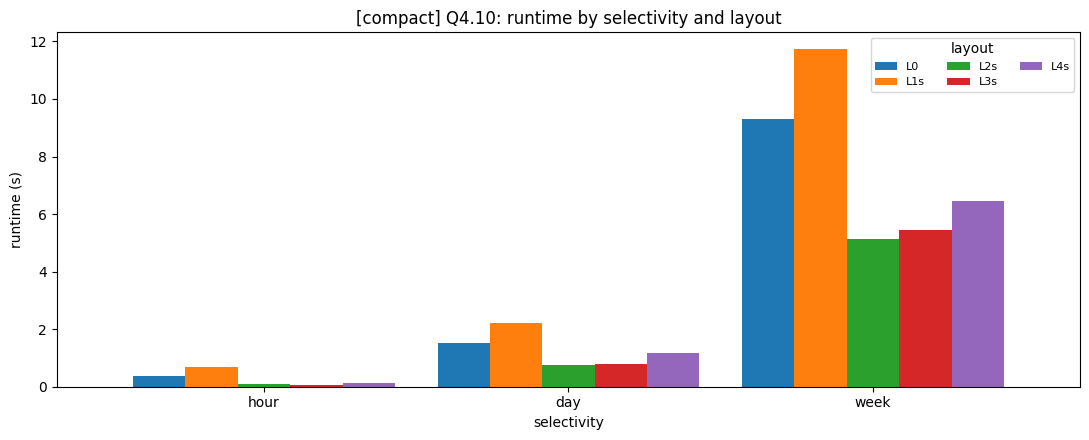

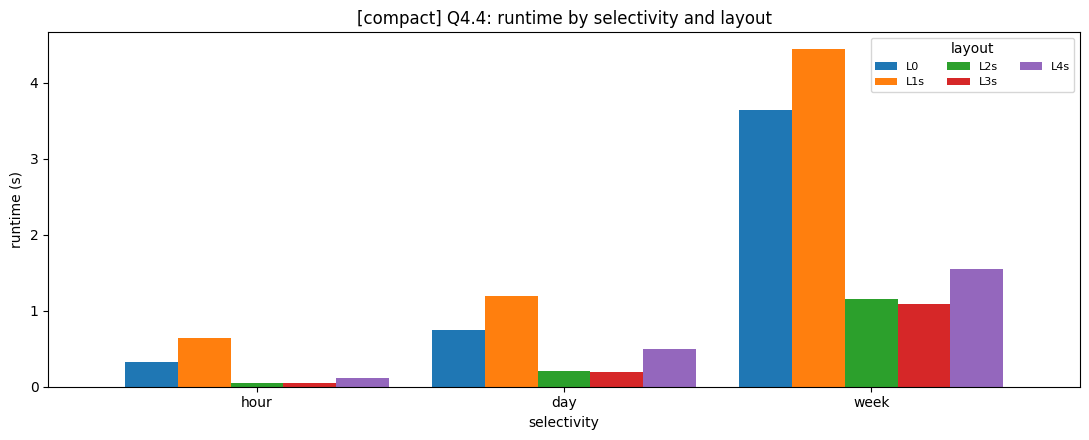

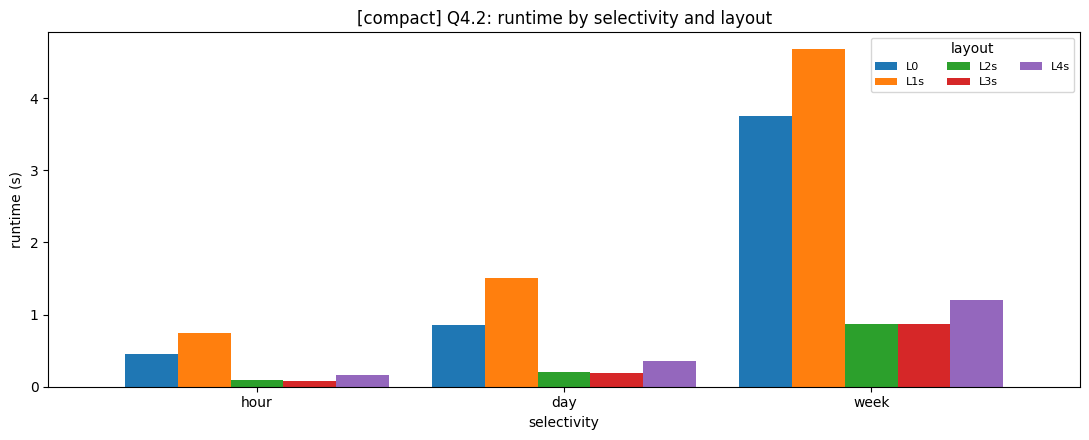

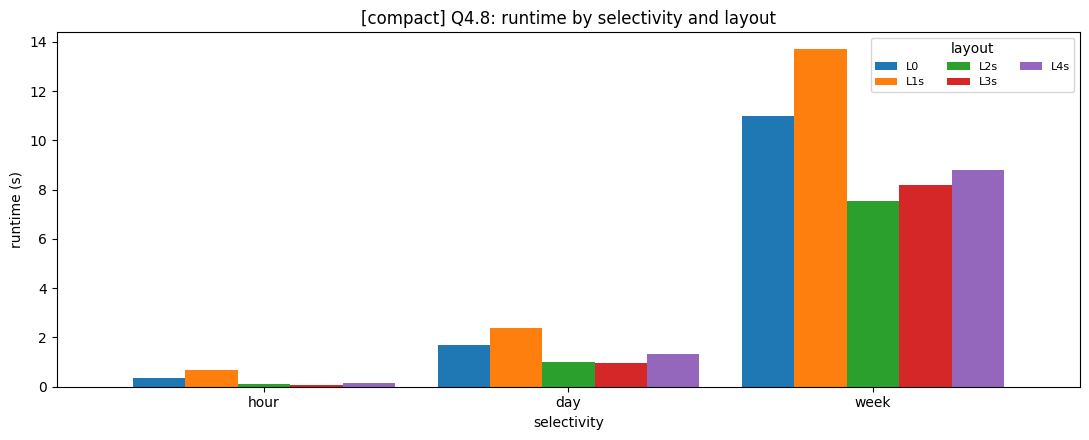

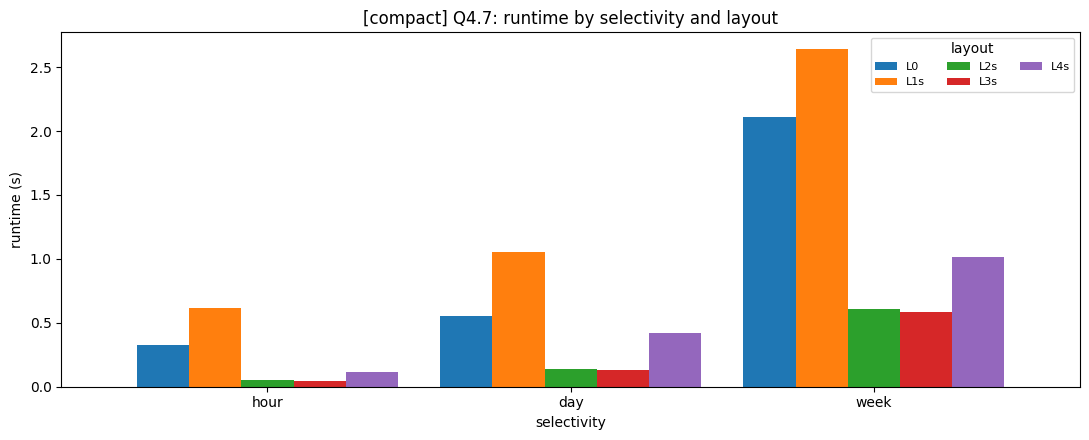

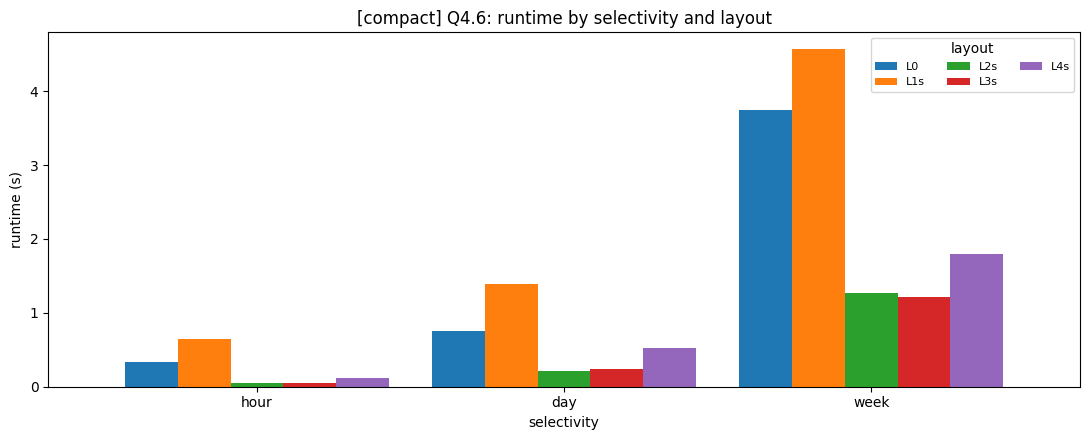

In [22]:
# Figure labels use the thesis names: layout names without the "_daily" storage
# suffix, and each benchmark query shown by its thesis number (Query 4.1..4.10 -> "Q4.1"..).
# This is a display-only patch applied at plt.show(): the underlying data keys, ORDER,
# and dict keys are untouched, so every merge/groupby/filter still works on the raw names.
import matplotlib.pyplot as plt
from pathlib import Path

# thesis Query numbering (Implementation chapter, in order of appearance).
# both spellings of harbor/harbour map to the same number.
QLABEL = {
    "both_ports": "Q4.1",
    "harbor_entry": "Q4.2", "harbour_entry": "Q4.2",
    "clip_to_region": "Q4.3",
    "fleet_summary": "Q4.4",
    "bounding_box": "Q4.5",
    "speed_profile": "Q4.6",
    "position_interpolation": "Q4.7",
    "nearest_approach": "Q4.8",
    "collision": "Q4.9",
    "encounter_zone": "Q4.10",
}

# Set FIG_OUT to a directory and every plt.show() also writes the figure there.
# Set FIG_NAME just before a plot to control that one file's name; it is cleared
# after use, so unnamed plots fall back to fig_NN.png.
FIG_OUT = None
_FIG_SEQ = [1]
_FIG_SEEN = set()

def _relabel(s):
    s = s.replace("_daily", "")
    for _name in sorted(QLABEL, key=len, reverse=True):   # longest first (no name is a substring of another, but safe)
        s = s.replace(_name, QLABEL[_name])
    return s

if not getattr(plt, "_thesis_patched", False):
    _orig_show = plt.show
    def _thesis_show(*args, **kwargs):
        for _fig in map(plt.figure, plt.get_fignums()):
            _st = getattr(_fig, "_suptitle", None)
            if _st is not None:
                _st.set_text(_relabel(_st.get_text()))
            for _ax in _fig.get_axes():
                for _axis in (_ax.xaxis, _ax.yaxis):
                    _tl = _axis.get_ticklabels()
                    if _tl and any(_relabel(_t.get_text()) != _t.get_text() for _t in _tl):
                        _axis.set_ticks(_axis.get_ticklocs())
                        _axis.set_ticklabels(
                            [_relabel(_t.get_text()) for _t in _tl],
                            rotation=_tl[0].get_rotation(), ha=_tl[0].get_ha())
                _ax.set_title(_relabel(_ax.get_title()))
                _leg = _ax.get_legend()
                if _leg:
                    for _t in _leg.get_texts():
                        _t.set_text(_relabel(_t.get_text()))
                for _t in _ax.texts:
                    _t.set_text(_relabel(_t.get_text()))
        if FIG_OUT:
            # Only figures not saved before: with a non-inline backend show()
            # leaves them open, so without this every call re-saves the whole
            # backlog.
            _new = [f for f in map(plt.figure, plt.get_fignums())
                    if id(f) not in _FIG_SEEN]
            _n = globals().get("FIG_NAME")
            for _i, _fig in enumerate(_new):
                _stem = _n if _n else f"fig_{_FIG_SEQ[0]:02d}"
                if len(_new) > 1:
                    _stem = f"{_stem}_{_i + 1}"
                _fig.savefig(Path(FIG_OUT) / f"{_stem}.png", dpi=150,
                             bbox_inches="tight", facecolor="white")
                _FIG_SEEN.add(id(_fig))
                _FIG_SEQ[0] += 1
            if _new:
                globals().pop("FIG_NAME", None)
        return _orig_show(*args, **kwargs)
    plt.show = _thesis_show
    plt._thesis_patched = True

ORDER_DAILY   = ["L0", "L1_daily", "L2_daily", "L3_daily", "L4_daily"]
ORDER_COMPACT = ["L0", "L1s", "L2s", "L3s", "L4s"]
ORDER_INFILE  = ["L0X", "L0Z", "L0H"]            # Exp 1 (in-file sort), analysed in 4e
ORDER = ORDER_DAILY + [l for l in ORDER_COMPACT if l not in ORDER_DAILY] + ORDER_INFILE
SELECTIVITY_ORDER = ["hour", "day", "week"]

def plot_runtime_by_query(df, *, queries, order, title_prefix):
    for query in queries:
        piv = df[df["query"] == query].pivot_table(index="selectivity", columns="layout", values="runtime_trimmed_s")
        piv = piv.reindex([s for s in SELECTIVITY_ORDER if s in piv.index])
        cols = [l for l in order if l in piv.columns]
        if not cols:
            continue
        ax = piv[cols].plot.bar(figsize=(11, 4.5), width=0.86)
        ax.set_ylabel("runtime (s)"); ax.set_xlabel("selectivity")
        ax.set_title(f"{title_prefix} {query}: runtime by selectivity and layout")
        ax.legend(title="layout", ncol=3, fontsize=8); ax.tick_params(axis="x", rotation=0)
        plt.tight_layout(); plt.show()

# Single benchmark CSV; `layout` is the unique key (L2s, L0X, L1_daily, …).
# Post-clock-sync results. results/iceberg.csv is kept as the pre-sync record:
# it was measured while the traj EWKB sat 3600 s behind its own tmin/tmax sidecars,
# which cost the finely tiled layouts most of their apparent recall. Point RESULTS
# back at it only to reproduce those older numbers.
RESULTS = next(p for p in ("results/iceberg_synced.csv",
                           "results/iceberg_synced.csv",
                           "results/iceberg_synced.csv",
                           "results/iceberg.csv") if Path(p).exists())
print(f"reading {RESULTS}")
ice = pd.read_csv(RESULTS)
QUERIES = sorted(ice["query"].unique())

plot_runtime_by_query(ice, queries=QUERIES, order=ORDER_DAILY,   title_prefix="[daily]")
plot_runtime_by_query(ice, queries=QUERIES, order=ORDER_COMPACT, title_prefix="[compact]")


### 4c. Overall speedup vs the L0 baseline

Per-query bars (4a) are detailed but hard to summarise -> collapse every query x time-window into a
typical speedup vs L0.  `speedup = time(L0) / time(layout)`: `2x` = twice as fast, `1x` = same, `<1x` = slower.

**geometric mean** is the right average for ratios: 4x on one query and 0.25x on another is honestly "even"
(1x), which the geomean gives (sqrt(4 * 0.25) = 1); a plain mean would say 2.1x. So we report the typical
multiplicative speedup. The dashed line at **1x** = "no faster than L0"; bars to the right are wins.

In [23]:
def geometric_mean(values):
    vals = pd.Series(values).dropna(); vals = vals[vals > 0]
    if vals.empty:
        return pd.NA
    return float(vals.prod() ** (1 / len(vals)))

def speedup_vs_baseline(runtime, baseline, order=ORDER):
    piv = runtime.pivot_table(index="case", columns="layout", values="runtime_s")
    if baseline not in piv.columns:
        raise ValueError(f"missing baseline layout: {baseline}")
    speedups = piv.rdiv(piv[baseline], axis=0)   # baseline_time / layout_time, per case
    speedups = speedups.reindex(columns=[l for l in order if l in speedups.columns])
    return speedups.apply(geometric_mean).dropna().sort_values()

def annotate_barh(ax, fmt="{:.2f}x"):
    x0, x1 = ax.get_xlim(); pad = (x1 - x0) * 0.012
    for patch in ax.patches:
        w = patch.get_width()
        ax.text(w + pad, patch.get_y() + patch.get_height() / 2, fmt.format(w), va="center", ha="left", fontsize=8)
    ax.set_xlim(x0, max(x1, max((p.get_width() for p in ax.patches), default=0) * 1.16))

def plot_speedup_barh(series, title, xlabel="typical speedup vs L0 (geometric mean)"):
    ax = series.plot.barh(figsize=(9, 5), color="#4c78a8")
    ax.axvline(1.0, color="k", lw=0.8, ls="--")
    ax.set_xlabel(f"{xlabel}  -  x"); ax.set_ylabel(""); ax.set_title(title)
    annotate_barh(ax); plt.tight_layout(); plt.show()

# one row per layout x query x window, straight from the single iceberg CSV
runtime = pd.read_csv("results/iceberg.csv").rename(columns={"runtime_trimmed_s": "runtime_s"})
runtime["case"] = runtime["query"].astype(str) + " (" + runtime["selectivity"] + ")"


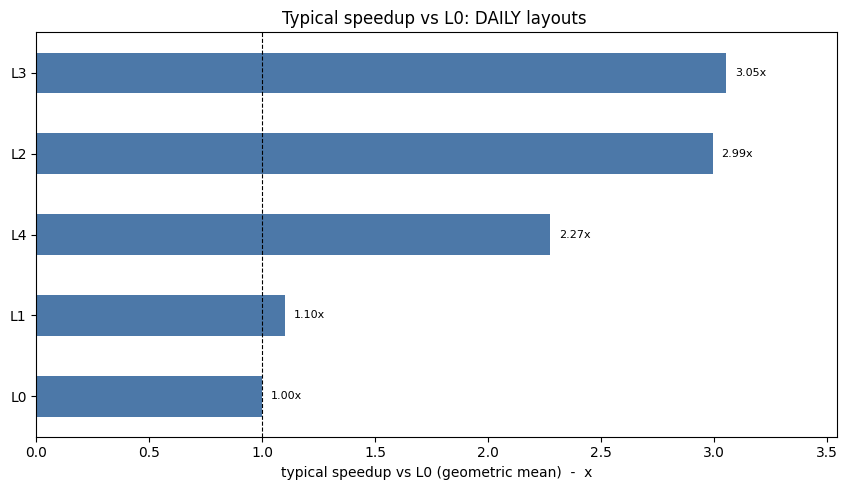

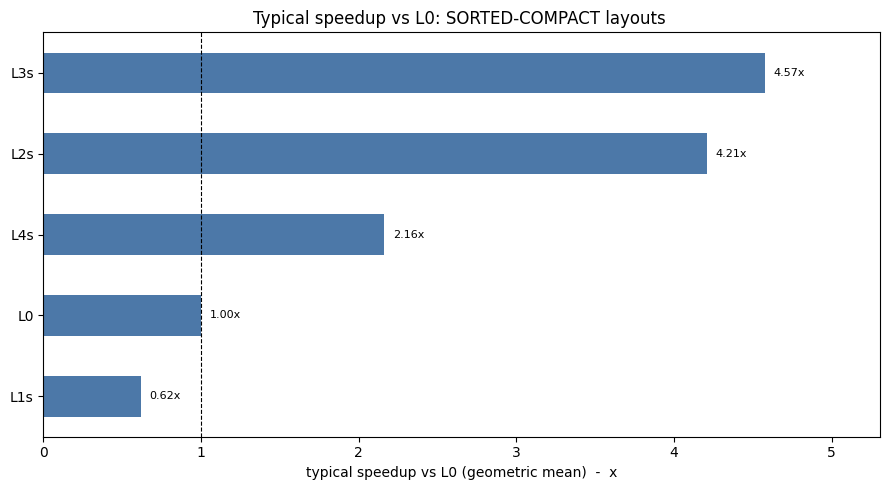

In [24]:
# 1 & 2: typical speedup vs L0, daily and sorted-compact families on separate figures.
plot_speedup_barh(speedup_vs_baseline(runtime, "L0", ORDER_DAILY),
                  "Typical speedup vs L0: DAILY layouts ")
plot_speedup_barh(speedup_vs_baseline(runtime, "L0", ORDER_COMPACT),
                  "Typical speedup vs L0: SORTED-COMPACT layouts ")

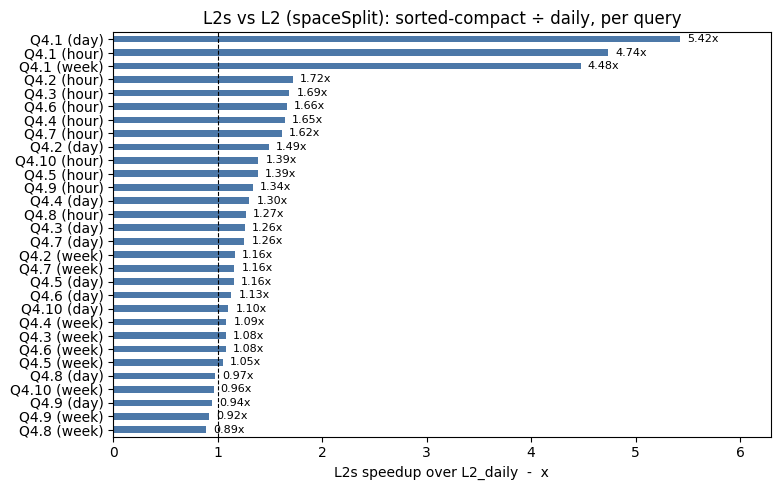

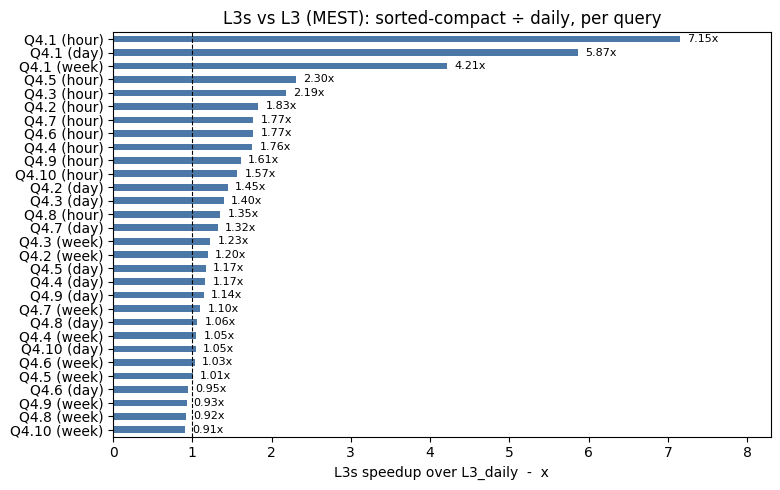

In [25]:
piv = runtime.pivot_table(index="case", columns="layout", values="runtime_s")
for tile, daily, sorted_ in [("spaceSplit", "L2_daily", "L2s"), ("MEST", "L3_daily", "L3s")]:
    if daily in piv.columns and sorted_ in piv.columns:
        ratio = (piv[daily] / piv[sorted_]).dropna().sort_values()
        plot_speedup_barh(ratio,
                          f"{sorted_} vs {daily} ({tile}): sorted-compact ÷ daily, per query",
                          xlabel=f"{sorted_} speedup over {daily}")


### 4d. Is the speedup worth the build cost?

A faster layout costs build time. Each layout is built on top of L0 (L0 = base segments), so its
real cost is `build(L0) + build(layout)`. This figure plots, for both Exp-2 families (daily, red; and
sorted-compact, blue), the extra build time (% of the L0 build, x-axis) against the typical
speedup vs L0 (geometric mean from 4c, y-axis). Top-left = cheap & fast (good); bottom-right =
expensive & slow.

Build times are summed `total_s` from the logs / `build_*.py`. Each sorted-compact layout costs
its daily twin's build + a cheap (~18 s) sort rewrite, so it sits directly above its twin:
~ the same build cost, but more speed. The hash one (L1s) stays below 1x, cheap to build but no
spatial pruning.

,family,extra_build_pct,speedup
layout,,,
L1,daily,3.9,1.1
L2,daily,218.0,3.0
L3,daily,234.9,3.1
L4,daily,150.8,2.3
L1s,sorted-compact,5.1,0.6
L2s,sorted-compact,219.4,4.2
L3s,sorted-compact,236.3,4.6
L4s,sorted-compact,152.3,2.2


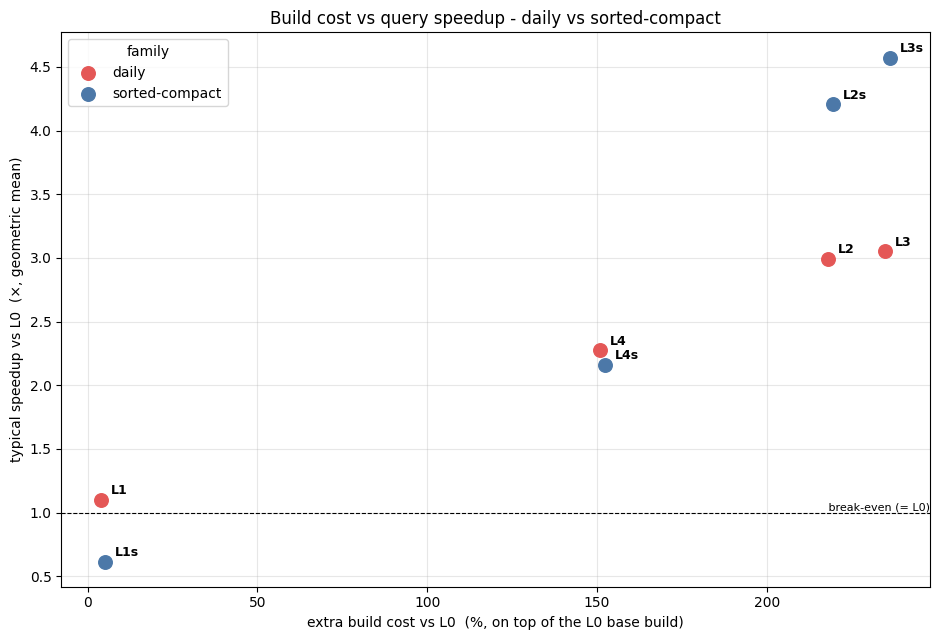

In [26]:
BUILD_S = {"L0": 1343.7, "L1_daily": 52.0, "L2_daily": 2901.1 + 28.2,
           "L3_daily": 3156.8, "L4_daily": 2025.9}
SORT_S = {"L1s": 16.2, "L2s": 18.7, "L3s": 18.9, "L4s": 20.2}
TWIN = {"L1s": "L1_daily", "L2s": "L2_daily", "L3s": "L3_daily", "L4s": "L4_daily"}
L0_BUILD = BUILD_S["L0"]

# Typical speedup vs L0
sp_daily = speedup_vs_baseline(runtime, "L0", ORDER_DAILY)
sp_comp = speedup_vs_baseline(runtime, "L0", ORDER_COMPACT)

rows = []
for layout in ["L1_daily", "L2_daily", "L3_daily", "L4_daily"]:
    rows.append({"layout": layout.replace("_daily", ""), "family": "daily",
                 "extra_build_pct": 100.0 * BUILD_S[layout] / L0_BUILD,
                 "speedup": float(sp_daily.get(layout, float("nan")))})
for layout in ["L1s", "L2s", "L3s", "L4s"]:
    extra = BUILD_S[TWIN[layout]] + SORT_S[layout]        # daily-twin build + the sort rewrite
    rows.append({"layout": layout, "family": "sorted-compact",
                 "extra_build_pct": 100.0 * extra / L0_BUILD,
                 "speedup": float(sp_comp.get(layout, float("nan")))})
cost = pd.DataFrame(rows).set_index("layout")
display(cost.round(1))

fig, ax = plt.subplots(figsize=(9.5, 6.5))
for fam, color in [("daily", "#e45756"), ("sorted-compact", "#4c78a8")]:
    sub = cost[cost.family == fam]
    ax.scatter(sub["extra_build_pct"], sub["speedup"], s=95, color=color, label=fam, zorder=3)
    for layout, r in sub.iterrows():
        ax.annotate(layout, (r["extra_build_pct"], r["speedup"]),
                    textcoords="offset points", xytext=(7, 4), fontsize=9, fontweight="bold")
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.text(ax.get_xlim()[1], 1.0, " break-even (= L0)", va="bottom", ha="right", fontsize=8, color="k")
ax.set_xlabel("extra build cost vs L0  (%, on top of the L0 base build)")
ax.set_ylabel("typical speedup vs L0  ( x , geometric mean)")
ax.set_title("Build cost vs query speedup - daily vs sorted-compact")
ax.legend(title="family")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4e. In-file ordering (Experiment 1): does the sort method matter?

`L0X` / `L0Z` / `L0H` = daily `L0` with rows sorted **in-file** by lexicographic / Z-order / Hilbert
(small row-groups), partition held = daily: this isolates the **sort method**. Uses the 5-iteration
trimmed run (`results/iceberg.csv` (iters=5)); a single cold-cache run overstated the effect. Finding: the
three methods sit within run-to-run noise (statistically **indistinguishable**), and in-file ordering
on a ~7.7k-row daily file gives **no measurable speedup**: it only pays off on the big month-compact
files (the `…s` family, §4a-4d). So sorted-compact uses lexicographic for *simplicity*, not a win.

In-file sort speedup vs L0 (geomean): {'L0X': 1.058, 'L0Z': 1.059, 'L0H': 1.032}
method spread max/min = 1.026x  ->  the three methods are statistically indistinguishable; in-file sort on daily gives ~no speedup


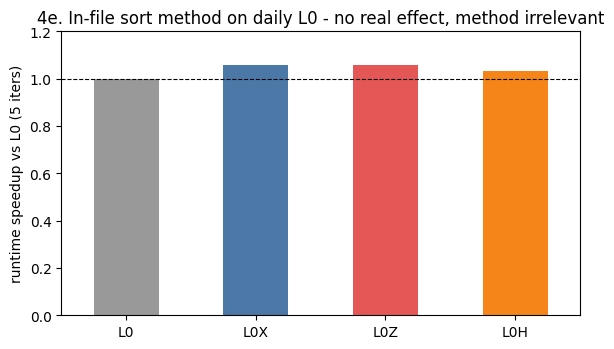

In [27]:
# Exp 1 - in-file sort method on daily L0, from the iters=5 benchmark.
e1 = pd.read_csv("results/iceberg.csv")
e1 = e1[e1.layout.isin(["L0", "L0X", "L0Z", "L0H"])]
p1 = e1.pivot_table(index=["query", "selectivity"], columns="layout", values="runtime_trimmed_s")
sp1 = {l: float(geometric_mean(p1["L0"] / p1[l])) for l in ["L0X", "L0Z", "L0H"]}
spread = max(sp1.values()) / min(sp1.values())
print("In-file sort speedup vs L0 (geomean):", {k: round(v, 3) for k, v in sp1.items()})
print(f"method spread max/min = {spread:.3f}x  ->  the three methods are statistically "
      f"indistinguishable; in-file sort on daily gives ~no speedup")

ax = pd.Series({"L0": 1.0, **sp1}).plot.bar(figsize=(6, 3.6), color=["#999", "#4c78a8", "#e45756", "#f58518"])
ax.axhline(1.0, color="k", lw=0.8, ls="--"); ax.set_ylim(0, 1.2)
ax.set_ylabel("runtime speedup vs L0 (5 iters)")
ax.set_title("4e. In-file sort method on daily L0 - no real effect, method irrelevant")
ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()


### 4f. Storage 

Every layout holds the same trajectories, so the total bytes are similar (~3.3-3.9 GB; the
`traj` blob dominates and compresses the same regardless of grouping). Two things differ a lot, and
both are real costs to weigh against the speed wins above:

- Row count: spatial tiling (L2 / L3) splits each trajectory segment at every tile border,
  so it stores ~17-22x more rows than the layouts that keep whole segments (L0, the L0X/L0Z/L0H
  in-file-sorted dailies, L1 hash). More rows = a bit more bytes and a lot more internal metadata.
- File count: from 16 files (L1s, huge files) to 4154(L2_daily, tiny files). Thousands
  of tiny files add open/metadata overhead; the sorted-compact `…s` layouts pack the same data into
  ~13x fewer files than their daily twins (e.g. L2s = 302 files vs L2_daily = 4154), which is a
  big part of why they're both fast and easier to manage.

,files,size_MB,rows,MB_per_file
layout,,,,
L0,31,3554.2,381713,114.65
L1_daily,496,3552.1,381713,7.16
L2_daily,4154,3826.5,6749935,0.92
L3_daily,4133,3889.6,8232719,0.94
L4_daily,744,3363.7,672860,4.52
L1s,16,3342.2,381713,208.89
L2s,302,3722.5,6749935,12.33
L3s,299,3793.6,8232719,12.69
L4s,24,3471.0,672860,144.62


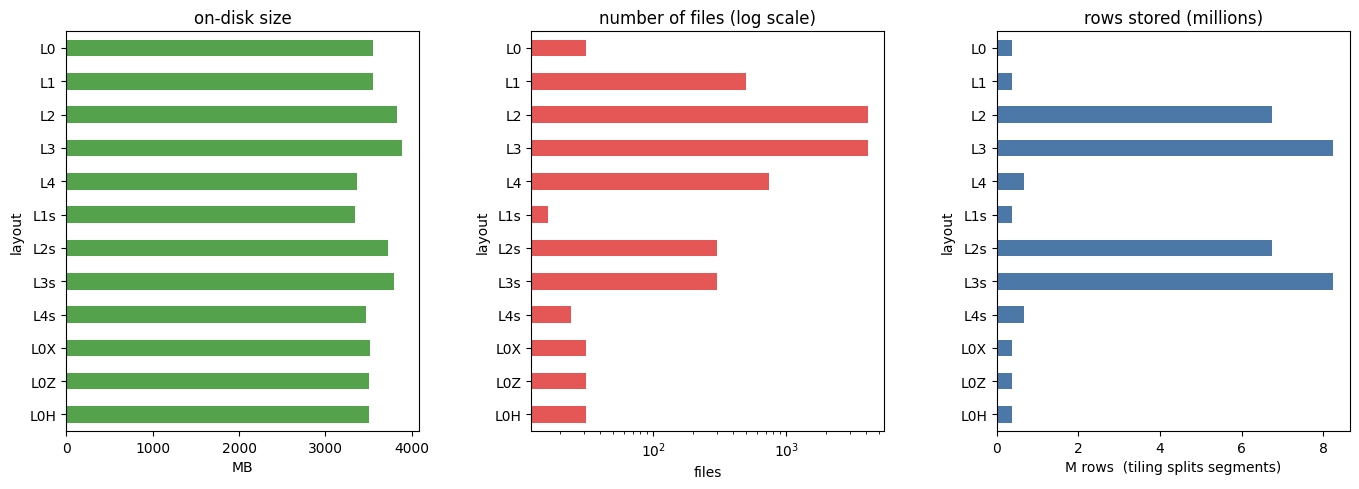

In [28]:
from lakehouse.query.registry import layouts as _layouts, trips_glob

srows = []
for ls in _layouts():
    g = trips_glob(ls)
    try:
        nf, rows = con.execute(
            f"SELECT count(DISTINCT file_name), sum(num_rows) "
            f"FROM parquet_file_metadata('{g}')").fetchone()
        size_mb = con.execute(
            f"SELECT sum(total_compressed_size)/1e6 FROM parquet_metadata('{g}')").fetchone()[0]
    except Exception:
        continue   # layout not built (e.g. experimental L2H) - no files match the glob
    if not nf:
        continue
    srows.append({"layout": ls.key, "files": int(nf), "size_MB": round(size_mb, 1),
                  "rows": int(rows), "MB_per_file": round(size_mb / nf, 2)})

storage = pd.DataFrame(srows).set_index("layout")
storage = storage.reindex([l for l in ORDER if l in storage.index] +
                          [l for l in storage.index if l not in ORDER])   # daily then sorted-compact
display(storage)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
storage["size_MB"].plot.barh(ax=axes[0], color="#54a24b")
axes[0].set_title("on-disk size"); axes[0].set_xlabel("MB"); axes[0].invert_yaxis()
storage["files"].plot.barh(ax=axes[1], color="#e45756")
axes[1].set_title("number of files (log scale)"); axes[1].set_xlabel("files"); axes[1].set_xscale("log"); axes[1].invert_yaxis()
(storage["rows"] / 1e6).plot.barh(ax=axes[2], color="#4c78a8")
axes[2].set_title("rows stored (millions)"); axes[2].set_xlabel("M rows  (tiling splits segments)"); axes[2].invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Data lake vs Lakehouse
Compare the classic data lake vs the lakehouse to isolate what the Iceberg catalog adds. Both sides run
the **same queries x windows** over the **identical Parquet** on MinIO; the two runs share one schema:

| side | script | result CSV | how it reads data |
|---|---|---|---|
| **data lake** | [-m lakehouse.query.run_parquet](-m lakehouse.query.run_parquet) | `results/parquet.csv` | `read_parquet(...)`, no catalog |
| **lakehouse** | [-m lakehouse.query.run_iceberg](-m lakehouse.query.run_iceberg) | `results/iceberg.csv` | `FROM lake.ais.<layout>`, manifest skips files first |

Regenerate either side with `python -m lakehouse.query.run_parquet --sels hour,day,week` /
`python -m lakehouse.query.run_iceberg --sels hour,day,week`.

360 paired rows (layout × query × window);  answer mismatches: 0


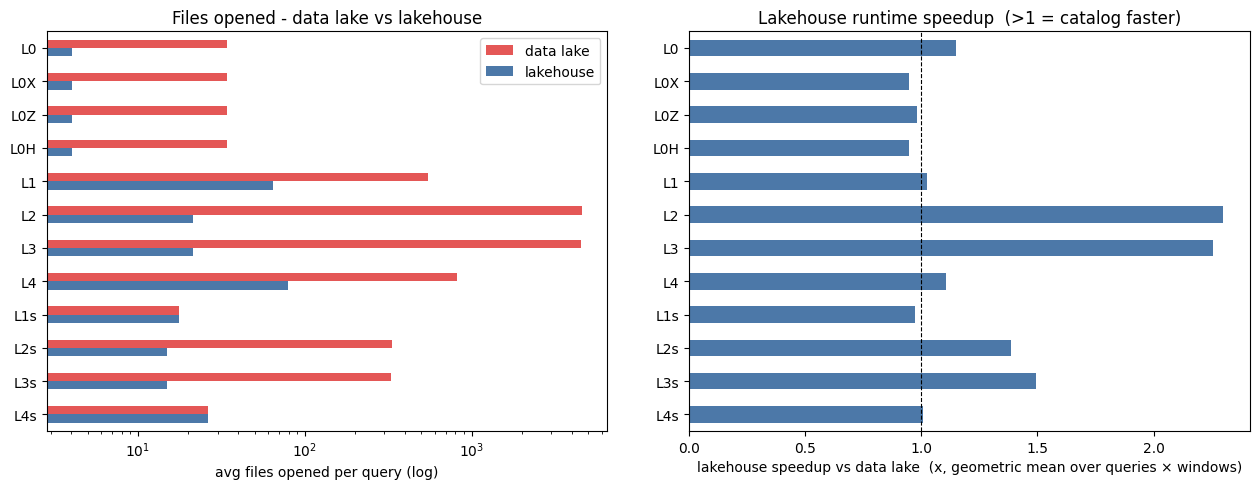

In [29]:
import numpy as np

KEYCOLS = ["layout", "gran", "query", "selectivity"]
dl = pd.read_csv(RESULTS.replace("iceberg","parquet"))    # data lake  (run_parquet.py)
lh = pd.read_csv(RESULTS)    # lakehouse  (run_queries.py)
cmp = dl.merge(lh, on=KEYCOLS, suffixes=("_dl", "_lh"))

bad = cmp[cmp.answer_dl.astype(str) != cmp.answer_lh.astype(str)]
print(f"{len(cmp)} paired rows (layout x query x window);  answer mismatches: {len(bad)}")
if len(bad):
    display(bad[KEYCOLS + ["answer_dl", "answer_lh"]])

cmp["files_skipped_pct"] = 100 * (1 - cmp.files_read_lh / cmp.files_read_dl)
cmp["lh_speedup_x"] = cmp.runtime_trimmed_s_dl / cmp.runtime_trimmed_s_lh

def geomean(s):
    s = pd.Series(s).dropna(); s = s[s > 0]
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

ORDER = ["L0", "L0X", "L0Z", "L0H", "L1_daily", "L2_daily", "L3_daily", "L4_daily",
         "L1s", "L2s", "L3s", "L4s"]
order = [l for l in ORDER if l in set(cmp.layout)]
summary = (cmp.groupby("layout")
              .agg(files_dl=("files_read_dl", "mean"), files_lh=("files_read_lh", "mean"),
                   lh_speedup_x=("lh_speedup_x", geomean))
              .reindex(order))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
summary[["files_dl", "files_lh"]].plot.barh(ax=axes[0], color=["#e45756", "#4c78a8"])
axes[0].set_xscale("log"); axes[0].invert_yaxis()
axes[0].set_xlabel("avg files opened per query (log)"); axes[0].set_ylabel("")
axes[0].set_title("Files opened - data lake vs lakehouse"); axes[0].legend(["data lake", "lakehouse"])
summary["lh_speedup_x"].plot.barh(ax=axes[1], color="#4c78a8")
axes[1].axvline(1.0, color="k", lw=0.8, ls="--"); axes[1].invert_yaxis()
axes[1].set_xlabel("lakehouse speedup vs data lake  (x, geometric mean over queries x windows)")
axes[1].set_ylabel(""); axes[1].set_title("Lakehouse runtime speedup  (>1 = catalog faster)")
plt.tight_layout(); plt.show()


## Related Work tutorial figure

Four AIS fixes that all fall *outside* the harbour box, but the interpolated
`tgeompoint` trajectory crosses it. This is the figure for the Related Work
trajectory-query tutorial. 


In [30]:
import os, re
import duckdb
import contextily as cx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pyproj import Transformer
from lakehouse.query.registry import MOBILITYDUCK_EXT

con_ = duckdb.connect(config={"allow_unsigned_extensions": "true"})
con_.execute(f"LOAD '{MOBILITYDUCK_EXT}';")
con_.execute("INSTALL spatial; LOAD spatial;")

con_.execute("""
CREATE OR REPLACE TEMP TABLE trip AS
SELECT tgeompointSeq(list_transform(
         list(struct_pack(ts := t, geom := ST_Point(lon, lat)) ORDER BY t),
         x -> tgeompoint(x.geom, x.ts))) AS traj
FROM (VALUES
  (TIMESTAMP '2026-01-15 08:05', 11.31, 54.580),
  (TIMESTAMP '2026-01-15 08:20', 11.33, 54.584),
  (TIMESTAMP '2026-01-15 08:45', 11.37, 54.597),
  (TIMESTAMP '2026-01-15 08:55', 11.39, 54.601)
) AS v(t, lon, lat);
""")

# the query: atGeometry returns the part of the path inside the box, with its timestamps
query = """
SELECT ST_AsText(trajectory(traj))   AS full_wkt,
       ST_AsText(trajectory(inside)) AS inside_wkt,
       startTimestamp(inside)        AS entered,
       endTimestamp(inside)          AS departed
FROM (
  SELECT traj,
         atGeometry(
           atTime(traj, span(TIMESTAMP '2026-01-15 08:00:00',
                             TIMESTAMP '2026-01-15 09:00:00', true, false)),
           ST_MakeEnvelope(11.34, 54.585, 11.36, 54.595)) AS inside
  FROM trip
) q;
"""
full_wkt, inside_wkt, entered, departed = con_.execute(query).fetchone()
print("entered:", entered, " departed:", departed)

entered: 2026-01-15 08:26:15+01:00  departed: 2026-01-15 08:38:44.999999+01:00


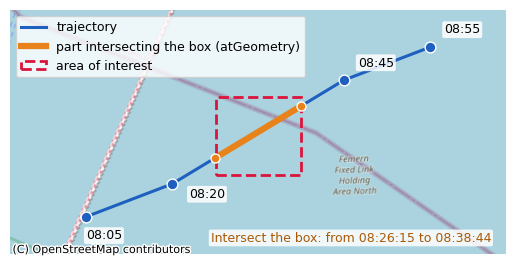

In [31]:
M = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True).transform
def coords(wkt):
    n = re.findall(r"-?\d+\.?\d*", wkt)
    return [(float(n[i]), float(n[i + 1])) for i in range(0, len(n), 2)]
full   = [M(lo, la) for lo, la in coords(full_wkt)]
inside = [M(lo, la) for lo, la in coords(inside_wkt)]
fx, fy = [p[0] for p in full], [p[1] for p in full]
ix, iy = [p[0] for p in inside], [p[1] for p in inside]
bx0, by0 = M(11.34, 54.585); bx1, by1 = M(11.36, 54.595)

samples = [("08:05", 11.31, 54.580), ("08:20", 11.33, 54.584),
           ("08:45", 11.37, 54.597), ("08:55", 11.39, 54.601)]
sm = [M(lo, la) for _, lo, la in samples]

WB = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85)  # text background
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(fx, fy, color="#1f5fbf", lw=2.2, zorder=3, label="trajectory")
ax.plot(ix, iy, color="#e8821a", lw=4.5, zorder=4, label="part intersecting the box (atGeometry)")
ax.scatter([p[0] for p in sm], [p[1] for p in sm], s=60, color="#1f5fbf", edgecolor="white", zorder=5)
ax.scatter(ix, iy, s=42, color="#e8821a", edgecolor="white", zorder=6)
offs = {0: (0, -16), 1: (12, -10), 2: (10, 10), 3: (10, 10)}
for i, ((t, _, _), (x, y)) in enumerate(zip(samples, sm)):
    ax.annotate(t, (x, y), textcoords="offset points", xytext=offs[i], fontsize=9, bbox=WB, zorder=7)
ax.add_patch(Rectangle((bx0, by0), bx1 - bx0, by1 - by0, fill=False, edgecolor="crimson",
                       lw=2.0, ls="--", zorder=4, label="area of interest"))
ax.text(0.97, 0.04, f"Intersect the box: from {entered:%H:%M:%S} to {departed:%H:%M:%S}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="#a85a06", bbox=WB, zorder=8)

allx, ally = fx + [bx0, bx1], fy + [by0, by1]
mx = (max(allx) - min(allx)) * 0.22; my = (max(ally) - min(ally)) * 0.22
ax.set_xlim(min(allx) - mx, max(allx) + mx); ax.set_ylim(min(ally) - my, max(ally) + my)
ax.set_aspect("equal")
cx.add_basemap(ax, crs="EPSG:32632", source=cx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off(); ax.legend(loc="upper left", frameon=True, fontsize=9)
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/tutorial_traj.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Pruning, correctness, and the layout trade-off

Sections 4-5 covered runtime, speedup, build cost and storage. This section adds the remaining legs of the evaluation, reusing the `ice`, `runtime`, `storage` and `cost` frames built above: the pruning result itself, a cross-layout correctness check, a per-query-class breakdown, the fragmentation that drives pruning, and one combined trade-off table. Run the notebook top-to-bottom so those frames exist.

In [32]:
# 6.0 Normalise the per-scan I/O metrics (fixes the >100% artifact).
# `both_ports` scans `trips` twice (one CTE per port), so a raw count sums both scans and can
# reach 200%. Divide by the number of trips-scans per query so each metric = % of ONE full scan.
# Computed from RAW counts, so this is idempotent (safe to re-run). We compare layouts on BYTES
# read (bytes_pct) - file count conflates pruning with fragmentation (justified in 6a').
SCANS = {"both_ports": 2}   # queries that scan `trips` more than once
ice["n_scans"] = ice["query"].map(SCANS).fillna(1).astype(int)
ice["files_pct"] = (100 * ice["files_read"] / (ice["files_total"] * ice["n_scans"])).round(1)
ice["bytes_pct"] = (100 * ice["bytes_read"] / (ice["bytes_total"] * ice["n_scans"])).round(3)
print("per-scan bytes_pct: max", round(ice["bytes_pct"].max(), 1),
      "%  (files_pct retained only for the 6a' justification)")

per-scan bytes_pct: max 86.5 %  (files_pct retained only for the 6a' justification)


### 6a. Pruning by layout: measured in **bytes read** (the headline data-skipping result)

We measure I/O as **bytes read from object storage** (`bytes_pct` = cold `total_bytes_read` per scan,
normalised by table size), not files opened. File count conflates data-skipping with fragmentation -
L2s/L3s open ~302 tiny tiles while L1s opens 16 large files - so it misranks layouts by up to ~8x
(shown in 6a'). Bytes read is the count-independent measure of how much data a query actually pulls.

selectivity,hour,day,week
layout,,,
L0,3.36,6.60,26.76
L0X,3.28,6.28,22.30
L0Z,2.80,5.98,23.14
L0H,2.57,5.57,20.32
L1_daily,3.23,6.27,26.43
L2_daily,0.24,0.50,2.19
L3_daily,0.24,0.50,2.19
L4_daily,1.38,4.47,24.59
L1s,41.49,51.50,66.75


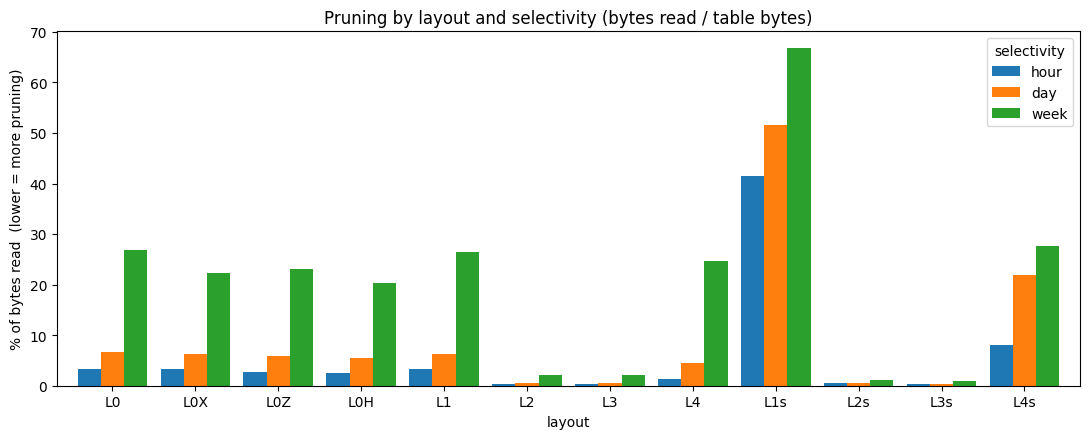

,bytes_pct_mean
layout,
L0,12.24
L0X,10.62
L0Z,10.64
L0H,9.49
L1_daily,11.98
L2_daily,0.98
L3_daily,0.98
L4_daily,10.15
L1s,53.25


In [33]:
# 6a. Pruning: % of bytes actually read after skipping (bytes_pct)
prune_piv = ice.pivot_table(index="layout", columns="selectivity", values="bytes_pct", aggfunc="mean")
sel_cols = [s for s in SELECTIVITY_ORDER if s in prune_piv.columns] or list(prune_piv.columns)
prune_piv = prune_piv[sel_cols].reindex([l for l in ORDER if l in prune_piv.index]).dropna(how="all")
display(prune_piv.round(2))

ax = prune_piv.plot.bar(figsize=(11, 4.5), width=0.84)
ax.set_ylabel("% of bytes read  (lower = more pruning)")
ax.set_xlabel("layout")
ax.set_title("Pruning by layout and selectivity (bytes read / table bytes)")
ax.legend(title="selectivity"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

prune_by_layout = (ice.groupby("layout")["bytes_pct"].mean()
                      .reindex([l for l in ORDER if l in set(ice.layout)]).dropna())
display(prune_by_layout.round(2).to_frame("bytes_pct_mean"))

### 6a′. Why bytes and not files (the file count is unreliable)

A one-time check that justifies measuring I/O in bytes everywhere above. `files_pct` counts file
*opens*, which conflates data-skipping with fragmentation: the spatial-tile layouts open many **tiny**
tiles (L2s/L3s: ~302 files of ~12 MB) while the hash layout opens few **large** ones (L1s: 16 files of
~209 MB). So the file count **over**-states real I/O by up to ~8x for fine-tiled layouts and
**under**-states it ~2x for the few-big-tile daily ones. Bytes read (the actual GET volume) is the
count-independent truth, so the rest of the analysis uses it.

,files_pct,bytes_pct
layout,,
L0,11.83,12.24
L0X,11.83,10.62
L0Z,11.83,10.64
L0H,11.83,9.49
L1_daily,11.83,11.98
L2_daily,0.47,0.98
L3_daily,0.47,0.98
L4_daily,9.71,10.15
L1s,100.00,53.25


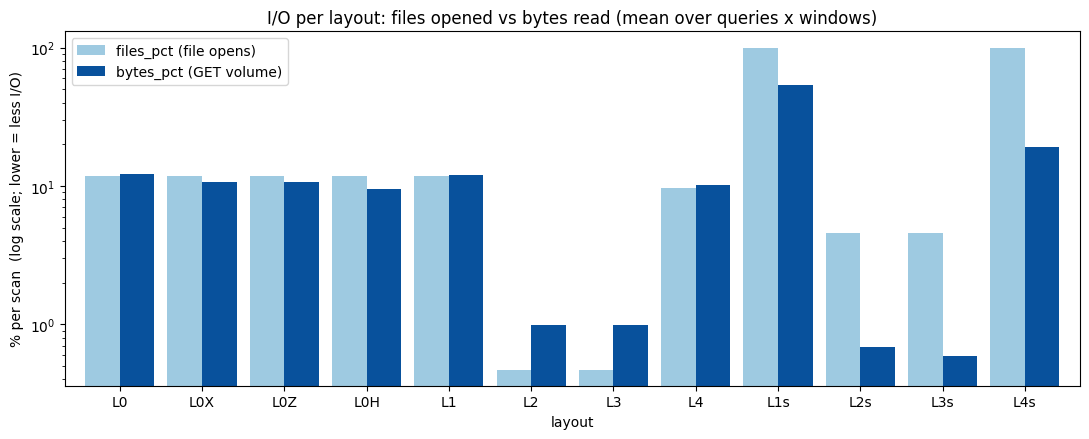

files_pct / bytes_pct per layout  (>1 = file count OVER-states real I/O, e.g. L3s ~8x; <1 = UNDER-states, e.g. L2/L3_daily ~2x):


,ratio_files_over_bytes
layout,
L3s,7.75
L2s,6.61
L4s,5.21
L1s,1.88
L0H,1.25
L0X,1.11
L0Z,1.11
L1_daily,0.99
L0,0.97


In [34]:
# 6a'. Files opened vs bytes read - proof that the file count is unreliable.
io = pd.DataFrame({
    "files_pct": ice.groupby("layout")["files_pct"].mean(),
    "bytes_pct": ice.groupby("layout")["bytes_pct"].mean(),
}).reindex([l for l in ORDER if l in set(ice.layout)]).dropna(how="all").round(2)
display(io)

ax = io.plot.bar(figsize=(11, 4.5), width=0.84, color=["#9ecae1", "#08519c"], logy=True)
ax.set_ylabel("% per scan  (log scale; lower = less I/O)")
ax.set_xlabel("layout")
ax.set_title("I/O per layout: files opened vs bytes read (mean over queries x windows)")
ax.legend(["files_pct (file opens)", "bytes_pct (GET volume)"])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

gap = (io["files_pct"] / io["bytes_pct"]).round(2).sort_values(ascending=False)
print("files_pct / bytes_pct per layout  (>1 = file count OVER-states real I/O, e.g. L3s ~8x;"
      " <1 = UNDER-states, e.g. L2/L3_daily ~2x):")
display(gap.to_frame("ratio_files_over_bytes"))

### 6b. Correctness: do all layouts return the same answer?

The layouts change only file grouping. A query that counts **distinct vessels** must give the same answer on every layout. But tiling (L2/L3/L4) splits each trajectory into the cells it crosses, so any metric that counts **segments / rows / pairs** will legitimately differ: that is expected, not a bug. Use this cell to separate the two: a vessel-level query that still disagrees is a real problem to fix. The spread reported below is a **tolerance from boundary splitting, not unresolved disagreement**: exact per-query accuracy is quantified as recall against the L0 ground truth in §8 (recall = answer / answer(L0)).

In [35]:
# 6b. Cross-layout answer agreement (tolerance from boundary splitting).
chk = ice.assign(answer=ice["answer"].astype(float))
spread = (chk.groupby(["query", "selectivity"])["answer"]
            .agg(lambda s: 100 * (s.max() - s.min()) / s.median() if s.median() else 0.0))
per_q = spread.groupby("query").max().sort_values(ascending=False)
g = chk.groupby(["query", "selectivity"])["answer"].nunique()
print("max cross-layout answer spread per query (% of median)")
print("  -> this is boundary-split tolerance; exact accuracy = recall vs L0 in section 8\n")
display(per_q.round(1).to_frame("max_spread_pct"))

max cross-layout answer spread per query (% of median)
  -> this is boundary-split tolerance; exact accuracy = recall vs L0 in section 8



,max_spread_pct
query,
both_ports,100.0
bounding_box,99.8
fleet_summary,89.3
harbour_entry,23.2
encounter_zone,15.9
collision,14.5
nearest_approach,9.1
speed_profile,6.7
position_interpolation,5.6


### 6c. Query taxonomy: which layout wins per class

Different query shapes reward different layouts. Group the queries into classes and report the best layout (highest geometric-mean speedup vs L0) per class, the "it depends, and here is the map" result. Edit `QUERY_CLASS` if the query set changes.

In [36]:
# 6c. Best layout per query class.
QUERY_CLASS = {
    "both_ports": "co-visit join (two ports)",
    "harbour_entry": "spatiotemporal range (port entry)",
    "clip_to_region": "spatiotemporal clip",
    "bounding_box": "aggregation (bbox)",
    "collision": "proximity self-join",
    "encounter_zone": "proximity / zone",
    "fleet_summary": "aggregation (fleet)",
    "nearest_approach": "nearest-approach",
    "position_interpolation": "reconstruction",
    "speed_profile": "aggregation (speed)",
}
rt = runtime.copy()
rt["qclass"] = rt["query"].astype(str).map(QUERY_CLASS).fillna("other")
base = rt[rt.layout == "L0"].set_index("case")["runtime_s"]
rt["speedup"] = [base.get(c, float("nan")) / t if t else float("nan")
                 for c, t in zip(rt["case"], rt["runtime_s"])]
cl = (rt.groupby(["qclass", "layout"])["speedup"].apply(geometric_mean).reset_index().dropna())
best = (cl.sort_values("speedup").groupby("qclass").tail(1)
          .set_index("qclass").sort_values("speedup", ascending=False)
          .rename(columns={"layout": "best_layout", "speedup": "geomean_speedup_vs_L0"}))
print("Best layout per query class (geometric-mean speedup vs L0):")
display(best.round(2))


Best layout per query class (geometric-mean speedup vs L0):


,best_layout,geomean_speedup_vs_L0
qclass,,
co-visit join (two ports),L3s,26.43
spatiotemporal clip,L3s,5.47
spatiotemporal range (port entry),L3s,4.78
reconstruction,L3s,4.75
aggregation (fleet),L3s,4.44
aggregation (bbox),L3s,4.21
aggregation (speed),L3s,4.06
proximity self-join,L3s,2.82
proximity / zone,L3s,2.57


### 6d. Fragmentation (replication factor)

Tiling stores a trajectory once per cell it crosses, so it holds more rows than the L0 base. That replication is the cost that buys pruning: replication = rows(layout) / rows(L0). Needs the `storage` frame from 4f.

,rows,size_MB,replication,bytes_pct_mean
layout,,,,
L0,381713,3554.2,1.00,12.24
L0X,381713,3511.3,1.00,10.62
L0Z,381713,3508.7,1.00,10.64
L0H,381713,3507.5,1.00,9.49
L1_daily,381713,3552.1,1.00,11.98
L2_daily,6749935,3826.5,17.68,0.98
L3_daily,8232719,3889.6,21.57,0.98
L4_daily,672860,3363.7,1.76,10.15
L1s,381713,3342.2,1.00,53.25


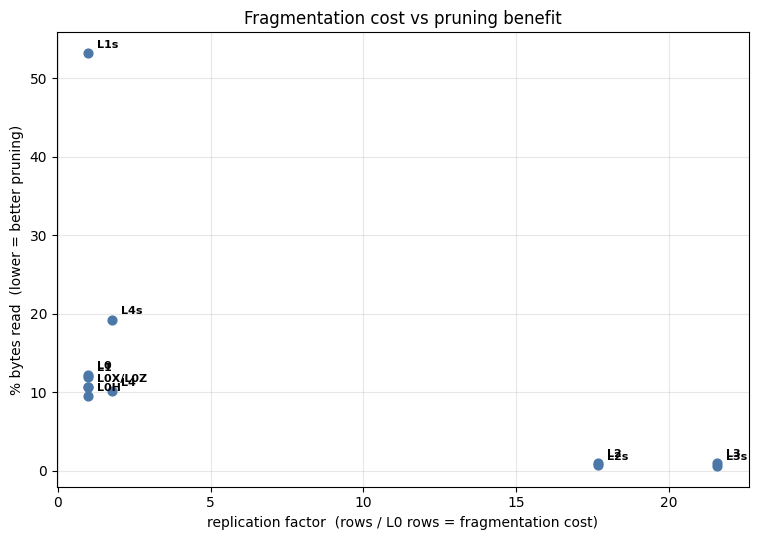

In [37]:
# 6d. Replication factor vs pruning. Needs the `storage` frame from 4f.
from collections import defaultdict
try:
    base_rows = storage.loc["L0", "rows"]
    frag = storage[["rows", "size_MB"]].copy()
    frag["replication"] = frag["rows"] / base_rows
    frag["bytes_pct_mean"] = ice.groupby("layout")["bytes_pct"].mean()
    frag = frag.reindex([l for l in ORDER if l in frag.index]).dropna(subset=["replication"])
    display(frag.round({"replication": 2, "size_MB": 1, "bytes_pct_mean": 2}))

    sub = frag.dropna(subset=["bytes_pct_mean"])
    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.scatter(sub["replication"], sub["bytes_pct_mean"], s=40, color="#4c78a8", zorder=3)
    grp = defaultdict(list)
    for layout, r in sub.iterrows():
        grp[(round(r["replication"], 1), round(r["bytes_pct_mean"], 1))].append(layout)
    for (x, y), ls in grp.items():
        ax.annotate("/".join(ls), (x, y), textcoords="offset points", xytext=(6, 4),
                    fontsize=8, fontweight="bold")
    ax.set_xlabel("replication factor  (rows / L0 rows = fragmentation cost)")
    ax.set_ylabel("% bytes read  (lower = better pruning)")
    ax.set_title("Fragmentation cost vs pruning benefit")
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
except (NameError, KeyError) as e:
    print("Run the storage cell (4f) first - needs the `storage` frame.", e)


### 6e. Layout trade-off table (benefit vs cost)

One row per layout: speedup and pruning (benefit) against storage, replication and build (cost). This is the decision view, pick the layout whose pruning and speedup justify its cost.

Layout trade-off (benefit vs cost):


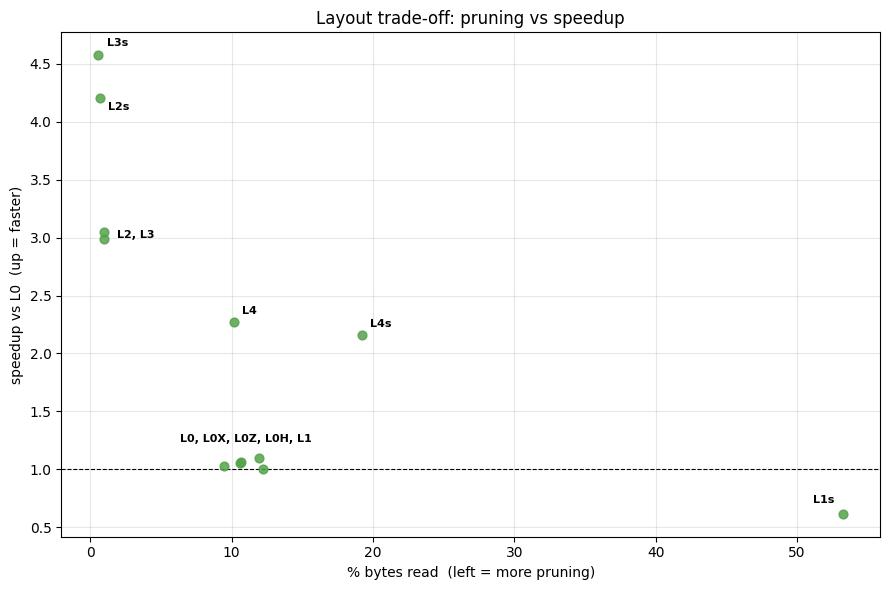

In [38]:
# 6e. Master trade-off: benefit (speedup, pruning) vs cost (storage, replication, build).
from collections import defaultdict
tradeoff = pd.DataFrame(index=[l for l in ORDER if l in set(ice.layout)])
tradeoff["bytes_pct_mean"] = ice.groupby("layout")["bytes_pct"].mean()
try:
    sp = speedup_vs_baseline(runtime, "L0", order=ORDER)
    tradeoff["speedup_vs_L0"] = sp
    tradeoff.loc["L0", "speedup_vs_L0"] = 1.0
except Exception as e:
    print("speedup unavailable:", e)
try:
    tradeoff["size_MB"] = storage["size_MB"]
    tradeoff["replication"] = storage["rows"] / storage.loc["L0", "rows"]
except Exception:
    pass
try:
    tradeoff["extra_build_pct"] = cost["extra_build_pct"]
except Exception:
    pass
tradeoff = tradeoff.dropna(how="all")
print("Layout trade-off (benefit vs cost):")

if {"speedup_vs_L0", "bytes_pct_mean"}.issubset(tradeoff.columns):
    t = tradeoff.dropna(subset=["speedup_vs_L0", "bytes_pct_mean"])
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(t["bytes_pct_mean"], t["speedup_vs_L0"], s=40, alpha=0.85, color="#54a24b", zorder=3)
    def _disp(l): return l.replace("_daily", "")
    # coincident clusters get one shared label so points do not overprint
    GROUPS = [(["L0", "L0X", "L0Z", "L0H", "L1_daily"], (0, 14, "center", "bottom")),
              (["L2_daily", "L3_daily"], (9, 0, "left", "center"))]
    grouped = set()
    for members, (dx, dy, ha, va) in GROUPS:
        m = [l for l in members if l in t.index]
        if not m:
            continue
        grouped.update(m)
        cx = t.loc[m, "bytes_pct_mean"].mean(); cy = t.loc[m, "speedup_vs_L0"].mean()
        ax.annotate(", ".join(_disp(l) for l in m), (cx, cy), textcoords="offset points",
                    xytext=(dx, dy), ha=ha, va=va, fontsize=8, fontweight="bold")
    OFF = {"L1s": (-6, 6, "right", "bottom"), "L4_daily": (6, 4, "left", "bottom"),
           "L4s": (6, 4, "left", "bottom"), "L2s": (6, -3, "left", "top"),
           "L3s": (6, 5, "left", "bottom")}
    for layout in t.index:
        if layout in grouped:
            continue
        dx, dy, ha, va = OFF.get(layout, (6, 4, "left", "bottom"))
        ax.annotate(_disp(layout), (t.loc[layout, "bytes_pct_mean"], t.loc[layout, "speedup_vs_L0"]),
                    textcoords="offset points", xytext=(dx, dy), ha=ha, va=va,
                    fontsize=8, fontweight="bold")
    ax.axhline(1.0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("% bytes read  (left = more pruning)")
    ax.set_ylabel("speedup vs L0  (up = faster)")
    ax.set_title("Layout trade-off: pruning vs speedup")
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


### 6f. Runtime stability (95% confidence intervals)

`lakehouse.query.run_iceberg` records `runtime_mean_s` and `runtime_std_s` per measurement, so this reports the **95%
CI half-width** as a percent of the mean runtimer. Uses the **Student-t** critical value (t=2.78 at n=5), not the normal 1.96 (which would understate the CI ~40%).

mean 95% CI half-width per layout, % of runtime (t=2.78, n=5; lower = more stable):


,ci95_pct
layout,
L0,1.8
L0X,2.3
L0Z,3.6
L0H,5.5
L1_daily,5.9
L2_daily,4.0
L3_daily,4.1
L4_daily,6.4
L1s,7.6


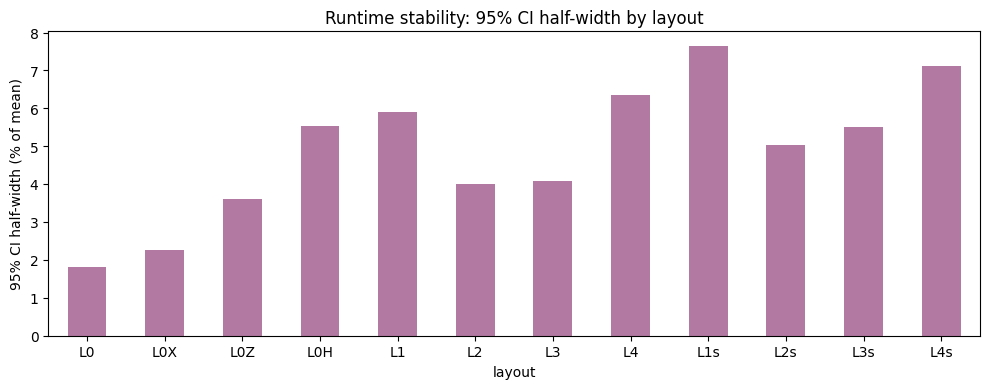

In [39]:
_T95 = {1: 12.706, 2: 4.303, 3: 3.182, 4: 2.776, 5: 2.571, 6: 2.447, 7: 2.365, 8: 2.306, 9: 2.262}
def _tcrit(nn): return _T95.get(int(nn) - 1, 1.96)   # df = n-1; ~normal (1.96) for large n
if "runtime_std_s" in ice.columns and "n_iters" in ice.columns:
    s = ice.copy()
    n = s["n_iters"].clip(lower=2)
    base = s["runtime_mean_s"] if "runtime_mean_s" in s.columns else s["runtime_median_s"]
    s["ci95_pct"] = 100 * n.map(_tcrit) * s["runtime_std_s"] / (n.pow(0.5) * base.replace(0, float("nan")))
    ci = (s.groupby("layout")["ci95_pct"].mean()
            .reindex([l for l in ORDER if l in set(s.layout)]).dropna())
    print(f"mean 95% CI half-width per layout, % of runtime (t={_tcrit(int(n.iloc[0])):.2f}, n={int(n.iloc[0])}; lower = more stable):")
    display(ci.round(1).to_frame("ci95_pct"))
    ax = ci.plot.bar(figsize=(10, 4), color="#b279a2")
    ax.set_ylabel("95% CI half-width (% of mean)"); ax.set_xlabel("layout")
    ax.set_title("Runtime stability: 95% CI half-width by layout")
    ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()
elif {"runtime_median_s", "runtime_min_s"}.issubset(ice.columns):
    s = ice.copy()
    s["spread_pct"] = 100 * (s["runtime_median_s"] - s["runtime_min_s"]) / s["runtime_median_s"]
    spread = (s.groupby("layout")["spread_pct"].mean()
                .reindex([l for l in ORDER if l in set(s.layout)]).dropna())
    display(spread.round(1).to_frame("spread_pct"))
    ax = spread.plot.bar(figsize=(10, 4), color="#b279a2")
    ax.set_ylabel("spread %"); ax.set_xlabel("layout"); ax.tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()


### 6g. Query selectivity (candidate rows after pushdown)

`rows_scanned` is the scan's *output* cardinality, the candidate rows that survive the pushed-down min/max predicate, i.e. the query's **selectivity**. Because that predicate is identical on every layout, this number is roughly layout-invariant: it measures how selective the *query* is, **not** how well a *layout* prunes. Layout pruning is the file-level `files_pct` in 6a (ideally bytes). Shown here per layout to confirm it stays ~constant.

Candidate rows after pushdown per layout - ~constant means it is query
selectivity, not layout pruning (the layout signal is bytes_pct, 6a):


,rows_pct (selectivity %)
layout,
L0,0.371
L0X,0.371
L0Z,0.371
L0H,0.371
L1_daily,0.371
L2_daily,0.149
L3_daily,0.155
L4_daily,0.250
L1s,0.371


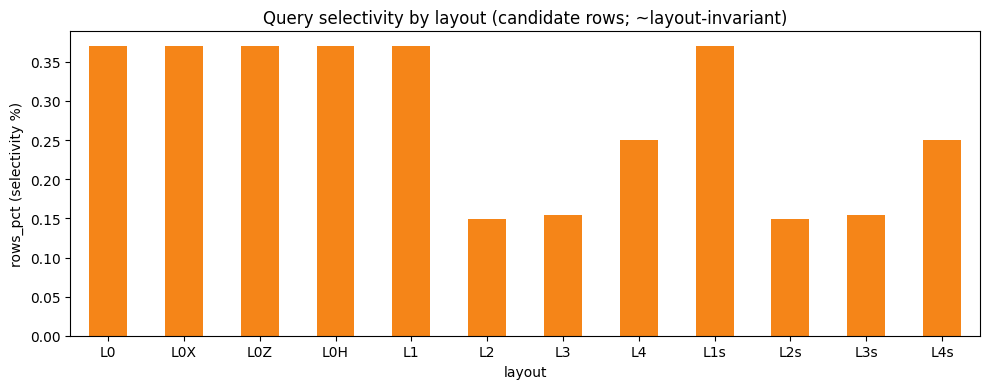

In [40]:
# 6g. Query selectivity: candidate rows after predicate pushdown 
if "rows_scanned" in ice.columns and ice["rows_scanned"].notna().any():
    r = ice.dropna(subset=["rows_scanned"]).copy()
    if "rows_pct" in r.columns:
        sel = (r.groupby("layout")["rows_pct"].mean()
                 .reindex([l for l in ORDER if l in set(r.layout)]).dropna())
        col = "rows_pct (selectivity %)"
    else:
        sel = (r.groupby("layout")["rows_scanned"].mean()
                 .reindex([l for l in ORDER if l in set(r.layout)]).dropna())
        col = "rows_scanned (mean)"
    print("Candidate rows after pushdown per layout - ~constant means it is query")
    print("selectivity, not layout pruning (the layout signal is bytes_pct, 6a):")
    display(sel.round(3).to_frame(col))
    ax = sel.plot.bar(figsize=(10, 4), color="#f58518")
    ax.set_ylabel(col); ax.set_xlabel("layout")
    ax.set_title("Query selectivity by layout (candidate rows; ~layout-invariant)")
    ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()
else:
    print("rows_scanned not in the CSV.")

### 6h. Spatial-selectivity sweep

`run_queries.py --spatial` runs a parameterised box query at a fixed time window over concentric boxes from ~0.1 km² (a port) to ~22 500 km², per layout, and writes `results/spatial.csv`. This isolates *spatial* pruning, the main benchmark sweeps only the time window. Run:

`python -m lakehouse.query.run_iceberg --spatial --iters 10`

*Reading it: lines are **flat** for layouts that don't partition by space (L0/L1/L4, a spatial box opens the same files at any size); only **L2/L3** fall as the box shrinks. Both axes are log so the L2/L3 curves aren't crushed under the 100% (read-everything) lines.*

*Note: many layouts prune spatially **identically** (the in-file-sort variants match L0; L2~L3; L1s~L4s), so the plot draws **one line per distinct curve** with a combined label - the full 12-layout table is shown below it.*

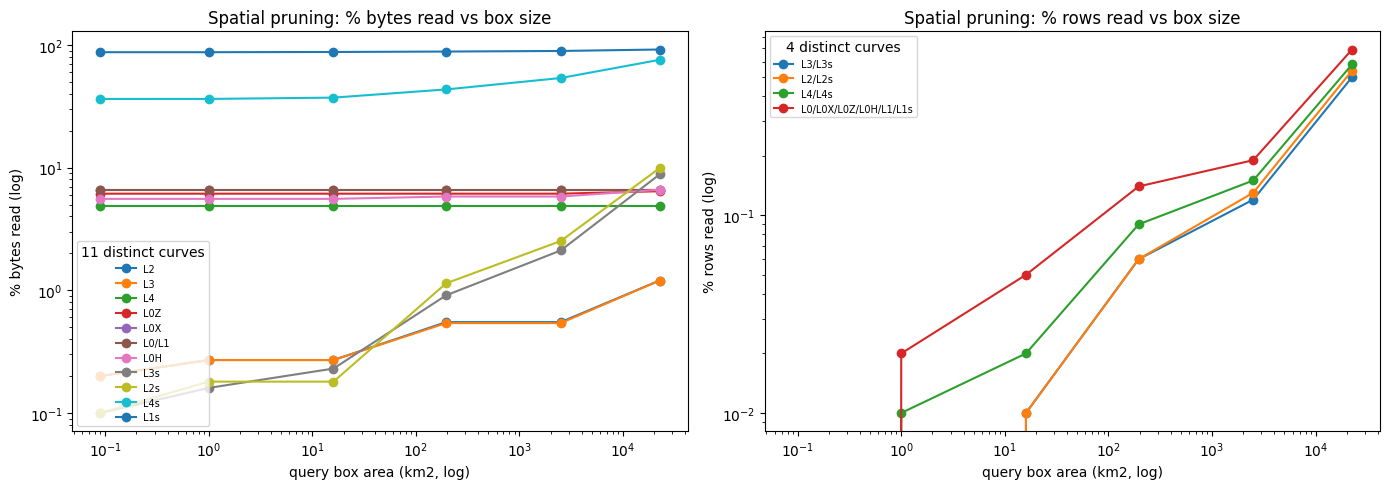

Per-layout bytes_pct (the 12 layouts behind the grouped lines):


spatial_km2,0.09,1.00,16.00,196.00,2500.00,22500.00
layout,,,,,,
L0,6.6,6.6,6.6,6.6,6.6,6.6
L0X,6.5,6.5,6.5,6.5,6.5,6.5
L0Z,6.1,6.1,6.1,6.1,6.1,6.4
L0H,5.6,5.6,5.6,5.8,5.8,6.6
L1_daily,6.6,6.6,6.6,6.6,6.6,6.6
L2_daily,0.2,0.3,0.3,0.5,0.5,1.2
L3_daily,0.2,0.3,0.3,0.5,0.5,1.2
L4_daily,4.8,4.8,4.8,4.8,4.8,4.8
L1s,87.2,87.2,87.6,88.3,89.3,91.8


In [41]:
from collections import defaultdict
try:
    sp = pd.read_csv("results/spatial.csv")
except FileNotFoundError:
    sp = None
    print("results/spatial.csv not found - run: python -m lakehouse.query.run_iceberg --spatial --iters 10")
if sp is not None and len(sp):
    have_rows = "rows_pct" in sp.columns and sp["rows_pct"].notna().any()
    xs = sorted(sp["spatial_km2"].unique())
    def grouped(ax, metric, ylabel):
        piv = (sp.pivot_table(index="layout", columns="spatial_km2", values=metric)
                 .reindex([l for l in ORDER if l in set(sp.layout)]))
        groups = defaultdict(list)
        for lay, row in piv.iterrows():
            groups[tuple(row.round(2).values)].append(lay)
        for curve, lays in sorted(groups.items(), key=lambda kv: kv[0][-1]):
            ax.plot(xs, list(curve), marker="o", label="/".join(lays))
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("query box area (km2, log)"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7, title=f"{len(groups)} distinct curves")
    ncols = 2 if have_rows else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5), squeeze=False)
    grouped(axes[0][0], "bytes_pct", "% bytes read (log)")
    axes[0][0].set_title("Spatial pruning: % bytes read vs box size")
    if have_rows:
        grouped(axes[0][1], "rows_pct", "% rows read (log)")
        axes[0][1].set_title("Spatial pruning: % rows read vs box size")
    plt.tight_layout(); plt.show()
    print("Per-layout bytes_pct (the 12 layouts behind the grouped lines):")
    display(sp.pivot_table(index="layout", columns="spatial_km2", values="bytes_pct")
              .reindex([l for l in ORDER if l in set(sp.layout)]).round(1))


### 6i. Cold- vs warm-cache runtime

The main benchmark is warm (the scan is pre-touched, then iterated). `run_queries.py --cold` opens a **fresh DuckDB connection per iteration**, clearing the engine buffer pool and Iceberg/httpfs metadata caches (connection setup is untimed). It does **not** flush the OS / MinIO page cache, so it is *engine-cold*. Run:

`python -m lakehouse.query.run_iceberg --cold --iters 5 --out results/iceberg_cold.csv`

cold/warm runtime ratio per layout (geomean; >1 = cold is slower):


,cold_penalty_x
layout,
L0,2.76
L0X,2.57
L0Z,2.49
L0H,2.26
L1_daily,2.65
L2_daily,1.49
L3_daily,1.54
L4_daily,3.30
L1s,7.45


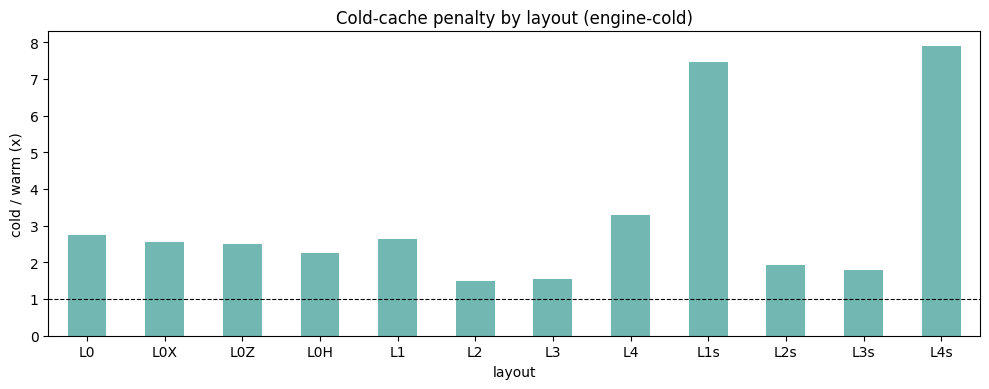

In [42]:
# 6i. Cold vs warm runtime. Needs a cold run: --cold --out results/iceberg_cold.csv
try:
    cold = pd.read_csv("results/iceberg_cold.csv")
except FileNotFoundError:
    cold = None
    print("results/iceberg_cold.csv not found - run:")
    print("  python -m lakehouse.query.run_iceberg --cold --iters 10 --out results/iceberg_cold.csv")
if cold is not None and len(cold):
    keys = ["layout", "query", "selectivity"]
    m = ice.merge(cold, on=keys, suffixes=("_warm", "_cold"))
    m["cold_penalty_x"] = m["runtime_trimmed_s_cold"] / m["runtime_trimmed_s_warm"]
    pen = (m.groupby("layout")["cold_penalty_x"].apply(geometric_mean)
             .reindex([l for l in ORDER if l in set(m.layout)]).dropna())
    print("cold/warm runtime ratio per layout (geomean; >1 = cold is slower):")
    display(pen.round(2).to_frame("cold_penalty_x"))
    ax = pen.plot.bar(figsize=(10, 4), color="#72b7b2")
    ax.axhline(1.0, color="k", lw=0.8, ls="--"); ax.set_ylabel("cold / warm (x)")
    ax.set_xlabel("layout"); ax.set_title("Cold-cache penalty by layout (engine-cold)")
    ax.tick_params(axis="x", rotation=0); plt.tight_layout(); plt.show()

## 7. Pipeline quality: cleaning & stop/move segmentation

The sections above evaluate the storage *layout*. This section evaluates the *pipeline* that produces the segments, cleaning and stop/move segmentation, from the local L0 base segments (`data/L0`). Reuses the `con` DuckDB connection from §1. (Move this section above the layout benchmarks in the final thesis if you prefer dataset-before-results ordering.)

*(Reads the `L0` trips projection via the catalog, the original-schema `data/L0` build input isn't kept; `quality_flags` therefore isn't shown.)*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Segments by type (stop vs move), from the L0 trips projection:


,segment_type,n_segments,n_vessels,avg_points,avg_duration_s,avg_length_m
0,stationary,214177,4287,590.1,12892.8,1892.6
1,in motion,167536,5212,758.2,6611.5,32595.8


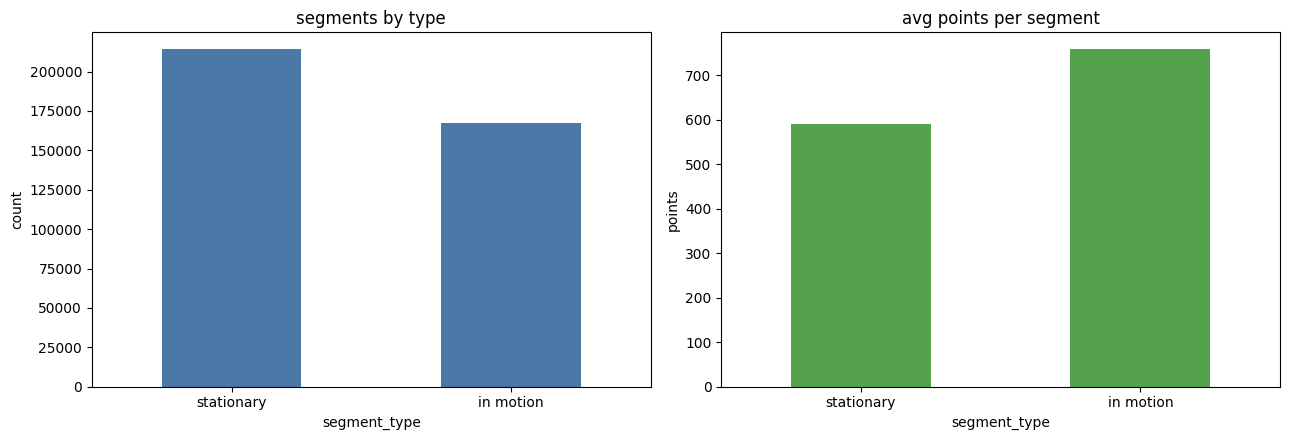

In [43]:
seg = con.execute("""
    SELECT segment_type,
           count(*)                                             AS n_segments,
           count(DISTINCT mmsi)                                 AS n_vessels,
           round(avg(numInstants(tgeompointFromEWKB(traj))), 1) AS avg_points,
           round(avg(date_diff('second', tmin, tmax)), 1)       AS avg_duration_s,
           round(avg(length(tgeompointFromEWKB(traj))), 1)      AS avg_length_m
    FROM lake.ais.L0
    GROUP BY segment_type ORDER BY n_segments DESC
""").df()
print("Segments by type (stop vs move), from the L0 trips projection:")
display(seg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
seg.set_index("segment_type")["n_segments"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("segments by type"); axes[0].set_ylabel("count"); axes[0].tick_params(axis="x", rotation=0)
seg.set_index("segment_type")["avg_points"].plot.bar(ax=axes[1], color="#54a24b")
axes[1].set_title("avg points per segment"); axes[1].set_ylabel("points"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()


## 8. Accuracy: recall vs the L0 reference

L0 keeps each vessel's stop/move segments whole, so it never loses a vessel to splitting and serves as the reference. Recall is **answer / answer(L0)** per query x window.

**Recall is only defined where the answer counts entities L0 maximises.** Six of the ten queries qualify:

| query | answer | |
|---|---|---|
| `both_ports`, `harbour_entry`, `clip_to_region`, `position_interpolation` | `count(DISTINCT mmsi)` | one-sided: tiling can lose a vessel, not invent one |
| `collision`, `encounter_zone` | `count(DISTINCT (m1,m2))` pairs | two-sided: a split path could also register a spurious pair, so >100% is possible |

The other four are **excluded**: `fleet_summary` returns `total_km`, `bounding_box` a mean area, `nearest_approach` a distance, `speed_profile` a speed. A ratio of those against L0 is not a recall - it is a conservation ratio, reported separately below as *length kept*.

Splitting turns out to cost very little, because the tiler does not truncate at a boundary: MEOS interpolates the crossing and emits it as the last instant of one fragment and the first of the next, so the fragments overlap at the seam and their union covers the parent path. What adaptive tiling (L3) does lose is stored path **length**, through a floating-point comparison in the step that assigns its variable-sized boxes to region cells - see `results/WHY_FRAGMENTS_ARE_LOST.md`.

Cells 8a-8c write the two thesis figures and the LaTeX table straight into the thesis tree.

In [44]:
# 8. Query answers by time window (Q4.1 through Q4.10, ordered)
# Dashboard showing all 10 queries with their L0 ground truth answers
Q_ORDER = ["both_ports", "harbor_entry", "harbour_entry", "clip_to_region", "fleet_summary",
           "bounding_box", "speed_profile", "position_interpolation", "nearest_approach", "collision", "encounter_zone"]
# Keep the spelling the data actually uses; the thesis label comes from QLABEL.
_have = set(ice["query"])
Q_ORDER = list(dict.fromkeys(q for q in Q_ORDER if q in _have))

# Get L0 answers for each query x window
l0_data = ice[ice.layout == "L0"][["query", "selectivity", "answer"]].copy()
l0_data["query_label"] = l0_data["query"].map(QLABEL)
l0_data["answer"] = pd.to_numeric(l0_data["answer"], errors="coerce")

# Pivot for each query
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

q_mapping = {q: QLABEL.get(q, q) for q in Q_ORDER}

for idx, q in enumerate(Q_ORDER):
    if idx >= 10: break
    q_data = l0_data[l0_data["query"] == q].dropna(subset=["answer"])
    if len(q_data) > 0:
        pivot = q_data.pivot_table(index="selectivity", values="answer", aggfunc="first")
        pivot = pivot.reindex(["hour", "day", "week"], fill_value=0)
        pivot.plot(kind="bar", ax=axes[idx], legend=False, color="steelblue")
        axes[idx].set_title(q, fontsize=10)
        axes[idx].set_xlabel("")
        axes[idx].set_ylabel("")
        axes[idx].set_xticklabels(["hour", "day", "week"], rotation=0)
        # Add value labels on bars
        for j, v in enumerate(pivot.values.flatten()):
            if v > 0:
                axes[idx].text(j, v, f"{int(v)}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Query answers on the L0 ground truth, by time window (one hour, one day, one week)", fontsize=12, y=0.995)
plt.tight_layout()
plt.savefig("figures/eval_query_answers_new.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: figures/eval_query_answers_new.png (original kept as eval_query_answers.png)")


In [ ]:
# 8a. Recall vs L0, and path length conserved.
#
# Recall is defined only where the answer counts entities L0 maximises. Adding a
# distance sum (fleet_summary) to this list would report a conservation ratio as
# if it were a recall, and dropping position_interpolation would omit a genuine
# count -- both were wrong here before.
COUNT_QUERIES = ["both_ports", "harbour_entry", "clip_to_region",
                 "position_interpolation", "collision", "encounter_zone"]
LENGTH_QUERY = "fleet_summary"          # total_km: conservation, not recall
FIGROOT = Path("figures")               # figures land here
FIGROOT.mkdir(exist_ok=True)

a = ice[ice["query"].isin(COUNT_QUERIES)].copy()
a["ans"] = pd.to_numeric(a["answer"], errors="coerce")
base = (a[a["layout"] == "L0"][["query", "selectivity", "ans"]]
          .rename(columns={"ans": "ans_L0"}))
a = a.merge(base, on=["query", "selectivity"], how="left")
a = a[a["ans_L0"].notna() & (a["ans_L0"] > 0)]
a["recall"] = a["ans"] / a["ans_L0"]

recall = (100 * a.groupby("layout")["recall"].mean()).reindex(
    [l for l in ORDER if l in set(a.layout)]).dropna()
worst = (100 * a.groupby("layout")["recall"].min()).reindex(recall.index)

f = ice[ice["query"] == LENGTH_QUERY].copy()
f["ans"] = pd.to_numeric(f["answer"], errors="coerce")
fb = (f[f["layout"] == "L0"][["selectivity", "ans"]]
        .rename(columns={"ans": "f0"}))
f = f.merge(fb, on="selectivity", how="left")
length = (100 * (f["ans"] / f["f0"])).groupby(f.layout).mean().reindex(recall.index)
byt = ice.groupby("layout")["bytes_pct"].mean().reindex(recall.index)

summary = pd.DataFrame({"recall_%": recall.round(2), "worst_cell_%": worst.round(2),
                        "length_kept_%": length.round(2), "bytes_%": byt.round(3)})
print("Recall counts entities; length_kept is a separate conservation ratio.")
display(summary)

off = a[a["recall"].round(4) != 1.0][["query", "selectivity", "layout",
                                      "ans_L0", "ans", "recall"]]
print(f"\n{len(off)} of {len(a)} (query x window x layout) cells differ from L0:")
display(off.assign(recall=(off["recall"] * 100).round(2)))

In [ ]:
# 8b. The two thesis figures, written into the thesis tree.
#
# Both changed form after the clock fix: recall is ~100% everywhere, so the old
# heatmap is one flat block of colour and the old recall-vs-pruning scatter is a
# horizontal line. The dot plot separates the two questions the numbers answer
# (entities recovered vs length conserved); the scatter keeps the old axes so it
# is comparable, with the y-axis zoomed to the range the data occupies.
BLUE, ORANGE = "#2a78d6", "#eb6834"   # validated categorical slots 1 and 2
INK, MUTED, GRID_C = "#0b0b0b", "#52514e", "#d8d7d2"
FIGDIR = FIGROOT
FIGDIR.mkdir(parents=True, exist_ok=True)
disp = [l.replace("_daily", "") for l in recall.index]

def _panel(ax, vals, xlim, xlabel):
    y = range(len(vals))
    ax.hlines(list(y), xlim[0], vals.values, color=GRID_C, lw=1, zorder=1)
    cols = [ORANGE if v < 99.99 else BLUE for v in vals.values]
    ax.scatter(vals.values, list(y), s=46, color=cols, zorder=3)
    for i, v in enumerate(vals.values):          # label only what deviates
        if v < 99.99:
            ax.annotate(f"{v:.2f}%", (v, i), textcoords="offset points",
                        xytext=(-8, 0), ha="right", va="center",
                        fontsize=8, color=ORANGE, fontweight="bold")
    ax.axvline(100, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
    ax.set_yticks(list(y)); ax.set_yticklabels(disp, fontsize=9, color=INK)
    ax.invert_yaxis(); ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.grid(axis="x", color=GRID_C, lw=0.6, alpha=0.7); ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID_C); ax.tick_params(colors=MUTED, length=0)

# No titles: the LaTeX caption carries the description.
fig, (p1, p2) = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
_panel(p1, recall, (99.5, 100.12), "% of $L0$'s count")
_panel(p2, length, (min(95.0, length.min() - 0.5), 100.6), "% of $L0$'s total km")
fig.tight_layout(); fig.savefig(FIGDIR / "eval_recall.png", dpi=200, facecolor="white")
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.set_xscale("log")
ax.scatter(byt.values, recall.values,
           s=52, color=[ORANGE if v < 99.99 else BLUE for v in recall.values], zorder=3)
# The lossless L0-family layouts sit on top of each other; one shared label.
CLUSTER = [l for l in ("L0", "L0X", "L0Z", "L0H", "L1_daily") if l in recall.index]
OFF = {"L2s": (0, 8, "center"), "L2_daily": (0, 8, "center"),
       "L3s": (0, -15, "center"), "L3_daily": (0, -15, "center"),
       "L4s": (0, 8, "center"), "L4_daily": (0, -15, "center"),
       "L1s": (-4, 8, "right")}
for l in recall.index:
    if l in CLUSTER:
        continue
    dx, dy, ha = OFF.get(l, (7, 6, "left"))
    ax.annotate(l.replace("_daily", ""), (byt[l], recall[l]), fontsize=8, color=INK,
                textcoords="offset points", xytext=(dx, dy), ha=ha)
if CLUSTER:
    cx = (byt[CLUSTER].min() * byt[CLUSTER].max()) ** 0.5
    ax.annotate(", ".join(c.replace("_daily", "") for c in CLUSTER), (cx, 100.0),
                textcoords="offset points", xytext=(0, 10), ha="center",
                fontsize=8, color=INK)
ax.axhline(100, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=2)
ax.set_ylim(min(99.93, recall.min() - 0.02), 100.045)
# Without this matplotlib factors out a "+1e2" offset and the axis reads
# 0.00 / -0.02 instead of 100.00 / 99.98 -- misleading on a recall axis.
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.set_xlabel("% of stored bytes read   (log scale; left = more pruning)",
              fontsize=9, color=MUTED)
ax.set_ylabel("recall vs $L0$  (%)", fontsize=9, color=MUTED)
ax.grid(color=GRID_C, lw=0.6, alpha=0.7); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID_C)
ax.tick_params(colors=MUTED)
fig.tight_layout()
fig.savefig(FIGDIR / "eval_recall_pruning.png", dpi=200, facecolor="white")
plt.show()
print(f"wrote {FIGDIR}/eval_recall.png and eval_recall_pruning.png")

## 9. Cleaning & segmentation: one vessel, one day

Why the pipeline cleans and segments before anything else. The **left** panel is the raw AIS stream for
one work vessel (MMSI 257584000) on 2026-01-15 - 40,973 position reports as an undifferentiated tangle.
The **right** panel is the same day after cleaning and segmentation: 33 labelled trajectory segments -
**blue = in motion** (16 trips), **red = stationary** (17 stops at 9 distinct berths). A ~1,200x
reduction that turns a raw point cloud into queryable, classified trips. Both on an OpenStreetMap
basemap at the same extent.

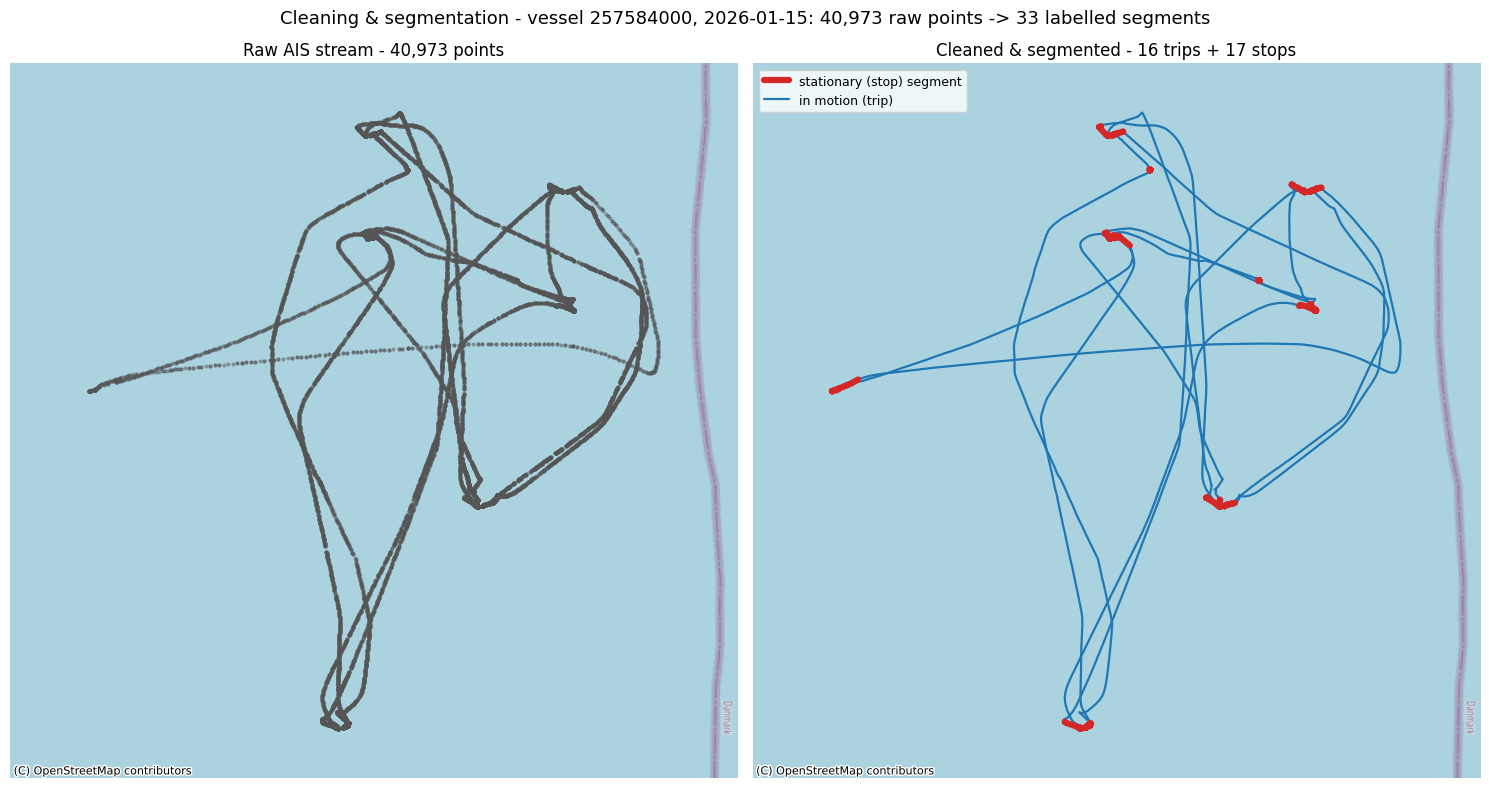

In [ ]:
import contextily as cx, numpy as np
from pyproj import Transformer

MMSI, DAY = 257584000, "2026-01-15"   # a work vessel: many short trips + stops at distinct berths

# raw AIS reports (WGS84) -> EPSG:32632 (match the cleaned trajectories + the basemap)
raw = con.execute(f"""SELECT longitude, latitude
    FROM read_parquet('data/raw/aisdk-{DAY}.parquet')
    WHERE mmsi = {MMSI} AND longitude BETWEEN -180 AND 180 AND latitude BETWEEN -90 AND 90""").df()
rx, ry = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True).transform(
    raw.longitude.values, raw.latitude.values)

# the cleaned, segmented trajectory (already EPSG:32632) - one row per segment
segs = con.execute(f"""SELECT segment_type, ST_AsText(trajectory(tgeompointFromEWKB(traj))) AS wkt
    FROM lake.ais.L0 WHERE mmsi = {MMSI} AND dt = DATE '{DAY}' ORDER BY tmin""").fetchall()
nmove = sum(1 for s, _ in segs if s != "stationary"); nstop = len(segs) - nmove

# shared, readable window from the cleaned bbox (clips any off-world garbage raw records)
bb = con.execute(f"""SELECT min(xmin), max(xmax), min(ymin), max(ymax)
    FROM lake.ais.L0 WHERE mmsi = {MMSI} AND dt = DATE '{DAY}'""").fetchone()
m = 0.08 * max(bb[1]-bb[0], bb[3]-bb[2]); X0, X1, Y0, Y1 = bb[0]-m, bb[1]+m, bb[2]-m, bb[3]+m

def _coords(wkt):
    out = []
    for g in re.findall(r"\(([^()]*)\)", wkt or ""):
        pts = [(float(p.split()[0]), float(p.split()[1])) for p in g.split(",") if len(p.split()) >= 2]
        if pts: out.append(pts)
    return out

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)
axL.scatter(rx, ry, s=4, color="#555555", alpha=0.4, zorder=2)
axL.set_title(f"Raw AIS stream - {len(raw):,} points", fontsize=12)

seen = set()
for stype, wkt in segs:
    move = stype != "stationary"
    color = "#1f77b4" if move else "#d62728"
    lab = "in motion (trip)" if move else "stationary (stop) segment"
    for line in _coords(wkt):
        xs, ys = zip(*line)
        kw = dict(label=lab if lab not in seen else None); seen.add(lab)
        # both are trajectory segments; draw both as lines, stops thicker (they are short)
        axR.plot(xs, ys, color=color, lw=(1.6 if move else 4.5),
                 solid_capstyle="round", zorder=(3 if move else 4), **kw)
axR.set_title(f"Cleaned & segmented - {nmove} trips + {nstop} stops", fontsize=12)
axR.legend(loc="upper left", fontsize=9)

for ax in (axL, axR):
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); ax.set_axis_off()
    try:
        cx.add_basemap(ax, crs="EPSG:32632", source=cx.providers.OpenStreetMap.Mapnik)
    except Exception as e:
        print("basemap skipped (no network?):", e)
fig.suptitle(f"Cleaning & segmentation - vessel {MMSI}, {DAY}: "
             f"{len(raw):,} raw points -> {len(segs)} labelled segments", fontsize=13)
plt.tight_layout()
import os; os.makedirs("figures", exist_ok=True)
fig.savefig("figures/clean_segment.png", dpi=200, bbox_inches="tight")
plt.show()

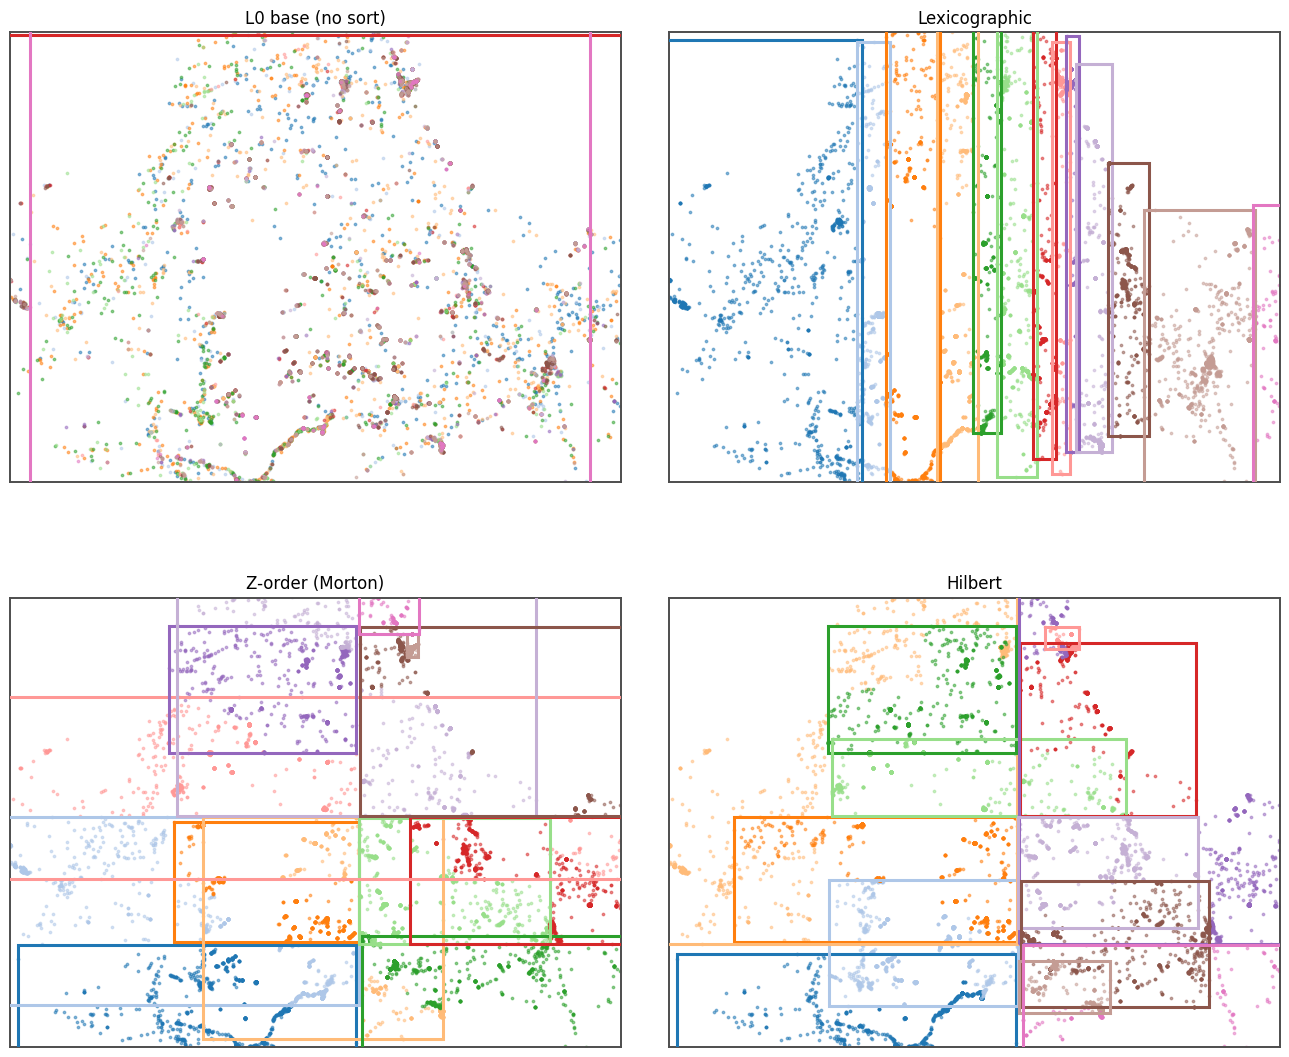

In [ ]:
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import duckdb
from lakehouse.query.registry import TRIPS_DEST

L0   = f"{TRIPS_DEST.rstrip('/')}/L0/L0/**/*.parquet"
DAY  = "2026-01-15"
CELL = 5000.0            # lexicographic sub-cell (m)
RG   = 1024              # Parquet row-group size
NB   = 1 << 16           # curve grid resolution

_c = duckdb.connect()
if str(TRIPS_DEST).startswith("s3://"):
    _c.execute("INSTALL httpfs; LOAD httpfs;")
    _c.execute("CREATE SECRET (TYPE S3, KEY_ID 'admin', SECRET 'password', "
               "ENDPOINT 'localhost:9000', URL_STYLE 'path', USE_SSL false, REGION 'us-east-1');")

x0, x1, y0, y1 = _c.execute(f"""
    SELECT quantile_cont((xmin+xmax)/2,0.005), quantile_cont((xmin+xmax)/2,0.995),
           quantile_cont((ymin+ymax)/2,0.005), quantile_cont((ymin+ymax)/2,0.995)
    FROM read_parquet('{L0}')""").fetchone()

df = _c.execute(f"""SELECT (xmin+xmax)/2.0 cx, (ymin+ymax)/2.0 cy, epoch(tmin) t
    FROM read_parquet('{L0}') WHERE dt = DATE '{DAY}'""").df()
n = len(df)
if n == 0:
    print(f"no L0 segments for {DAY} under {L0} - build the L0 trips projection first")
else:
    cx, cy, t = df.cx.to_numpy(), df.cy.to_numpy(), df.t.to_numpy()
    ix = np.clip(((cx - x0) / (x1 - x0) * (NB - 1)).astype(int), 0, NB - 1)
    iy = np.clip(((cy - y0) / (y1 - y0) * (NB - 1)).astype(int), 0, NB - 1)

    def morton(a, b):
        def p(v):
            v &= 0xFFFF
            v = (v | (v << 8)) & 0x00FF00FF; v = (v | (v << 4)) & 0x0F0F0F0F
            v = (v | (v << 2)) & 0x33333333; v = (v | (v << 1)) & 0x55555555
            return v
        return p(a) | (p(b) << 1)

    def xy2d(a, b):
        d = 0; s = NB // 2
        while s > 0:
            rx = 1 if (a & s) > 0 else 0; ry = 1 if (b & s) > 0 else 0
            d += s * s * ((3 * rx) ^ ry)
            if ry == 0:
                if rx == 1: a = s - 1 - a; b = s - 1 - b
                a, b = b, a
            s //= 2
        return d

    zk = np.fromiter((morton(int(a), int(b)) for a, b in zip(ix, iy)), np.int64, n)
    hk = np.fromiter((xy2d(int(a), int(b))  for a, b in zip(ix, iy)), np.int64, n)
    xc = np.floor(cx / CELL).astype(np.int64); yc = np.floor(cy / CELL).astype(np.int64)

    # np.lexsort uses the LAST key as primary -> matches ORDER BY xc, yc, t  /  zk, t  /  hk, t
    orders = {"L0 base (no sort)": np.arange(n),
              "Lexicographic":     np.lexsort((t, yc, xc)),
              "Z-order (Morton)":  np.lexsort((t, zk)),
              "Hilbert":           np.lexsort((t, hk))}

    vx0, vx1 = np.percentile(cx, [1, 99]); vy0, vy1 = np.percentile(cy, [1, 99])
    starts = list(range(0, n, RG))          # one slice per row group (1024 segments each)
    cmap = plt.get_cmap("tab20" if len(starts) > 10 else "tab10")
    fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)
    for ax, (name, order) in zip(axes.flat, orders.items()):
        ocx, ocy = cx[order], cy[order]
        for j, s in enumerate(starts):       # colour EVERY row group + draw its bbox
            gx, gy = ocx[s:s+RG], ocy[s:s+RG]
            col = cmap(j % cmap.N)
            ax.scatter(gx, gy, s=3, color=col, alpha=0.5, zorder=2)
            ax.add_patch(Rectangle((gx.min(), gy.min()), gx.max()-gx.min(), gy.max()-gy.min(),
                                   fill=False, edgecolor=col, lw=2.2, zorder=4))
        ax.set_xlim(vx0, vx1); ax.set_ylim(vy0, vy1); ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])           # no ticks, but keep a frame per sub-figure
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor("0.3"); sp.set_linewidth(1.4)
        ax.set_title(name, fontsize=12)
    plt.tight_layout(); fig.subplots_adjust(wspace=0.08, hspace=0.12)
    os.makedirs("figures", exist_ok=True)
    fig.savefig("figures/inorder_real.png", dpi=200, bbox_inches="tight")
    plt.show()


## 10. Memory spot-check (proximity self-joins)

Peak memory for the O(n²) proximity self-joins (`collision`, `encounter_zone`) across **all layouts** -
a worse-pruning layout feeds more candidate trajectories into the join and can peak higher. Because the
layouts run sequentially in one process and the OS does not reclaim freed buffers, the absolute
`peak_rss_mb` only ever climbs over the run; the fair cross-layout metric is **`mem_delta_mb`** - each
query's RSS growth over its own post-setup baseline (data buffered + join working set). Generated with:

`python -m lakehouse.query.run_iceberg --mem --queries collision,encounter_zone --sels day --iters 5`

per-query memory growth mem_delta_mb (MB) by query x layout  (fair cross-layout metric):


layout,L0,L0X,L0Z,L0H,L1_daily,L2_daily,L3_daily,L4_daily,L1s,L2s,L3s,L4s
query,,,,,,,,,,,,
Q5.9,203.0,474.0,292.0,396.0,110.0,10.0,5.0,111.0,2130.0,20.0,3.0,664.0
Q5.10,284.0,226.0,209.0,350.0,157.0,207.0,43.0,1.0,1373.0,1.0,0.0,1036.0


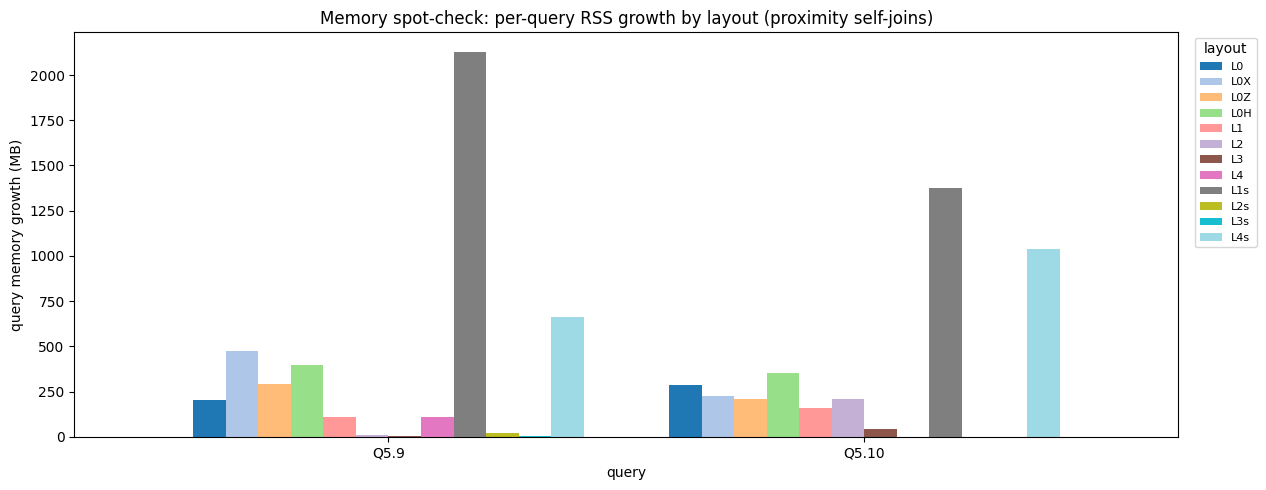

,layout,query,selectivity,files_read,peak_rss_mb,base_rss_mb,mem_delta_mb,runtime_trimmed_s
0,L0,collision,day,2,1280.7,1078.1,202.6,1.497837
1,L0,encounter_zone,day,2,1307.7,1024.0,283.7,1.535787
2,L0X,collision,day,2,1375.4,901.4,474.0,1.364843
3,L0X,encounter_zone,day,2,1426.9,1200.8,226.1,1.395026
4,L0Z,collision,day,2,1392.5,1100.3,292.2,1.360684
5,L0Z,encounter_zone,day,2,1345.4,1136.1,209.3,1.420228
6,L0H,collision,day,2,1370.4,974.0,396.4,1.350696
7,L0H,encounter_zone,day,2,1386.7,1036.4,350.2,1.425636
8,L1_daily,collision,day,32,968.1,858.0,110.1,1.337931
9,L1_daily,encounter_zone,day,32,930.4,773.4,157.0,1.396296


In [ ]:
# 10. Memory spot-check from results/mem.csv (run_queries.py --mem).
try:
    mem = pd.read_csv("results/mem.csv")
except FileNotFoundError:
    mem = None
    print("results/mem.csv not found - run:")
    print("  python -m lakehouse.query.run_iceberg --mem --queries collision,encounter_zone --sels day --iters 5")
if mem is not None and len(mem):
    piv = mem.pivot_table(index="query", columns="layout", values="mem_delta_mb", aggfunc="max")
    piv = piv[[l for l in ORDER if l in piv.columns]]
    print("per-query memory growth mem_delta_mb (MB) by query x layout  (fair cross-layout metric):")
    display(piv.round(0).rename(index=QLABEL))
    ax = piv.plot.bar(figsize=(13, 5), colormap="tab20", width=0.82)
    ax.set_ylabel("query memory growth (MB)"); ax.set_xticklabels([QLABEL.get(q, q) for q in piv.index], rotation=45, ha="right")
    ax.set_title("Memory spot-check: per-query RSS growth by layout (proximity self-joins)")
    ax.legend(title="layout", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()
    cols = ["layout", "query", "selectivity", "files_read", "peak_rss_mb", "base_rss_mb",
            "mem_delta_mb", "runtime_trimmed_s"]
    display(mem[[c for c in cols if c in mem.columns]].reset_index(drop=True))

## 11. Tile-size sweep

The main benchmark holds the spatial layouts' region cell at **50 km**. This section sweeps that choice.

- **11a (runs anywhere, seconds):** the *file-level model*, from the L0 segments' stored bounds alone, compute for each cell size how many cell files the layout produces, how often segments straddle cells, and what share of stored bytes a query region's cells hold. Writes `tile_size_model.csv` / `.json` and `figures/eval_tile_size.png` (used by the thesis).
- **11b (needs MobilityDuck + the MinIO/Iceberg stack, ~hours):** the *end-to-end sweep*, rebuild L2/L3 at 25 km and 100 km, register them, and run the full benchmark. Writes `results/tile_sweep.csv`.
- **11c:** analyse `results/tile_sweep.csv` against the 50 km reference (bytes read, runtime, recall vs L0).

In [ ]:
# 11a. File-level tile-size model (no MEOS needed; ~seconds).
# Writes tile_size_model.csv / .json and figures/eval_tile_size.png
%run experiments/evaluation/scripts/tile_size_model.py

import pandas as pd
tsm = pd.read_csv("tile_size_model.csv")
tsm

L0 segments: 381,713  trajectory bytes: 7.35 GB


{'cell_km': 12.5, 'files_compact': 31873, 'repl_rows': 8.353, 'repl_bytes': 65.769, 'share_rodby_port_pct': 0.145, 'cells_rodby_port': 1, 'share_puttgarden_port_pct': 0.114, 'cells_puttgarden_port': 1, 'share_goteborg_port_pct': 0.426, 'cells_goteborg_port': 4, 'share_belt_pct': 0.495, 'cells_belt': 4}


{'cell_km': 25.0, 'files_compact': 8076, 'repl_rows': 3.165, 'repl_bytes': 19.276, 'share_rodby_port_pct': 0.517, 'cells_rodby_port': 1, 'share_puttgarden_port_pct': 0.417, 'cells_puttgarden_port': 1, 'share_goteborg_port_pct': 1.797, 'cells_goteborg_port': 4, 'share_belt_pct': 1.783, 'cells_belt': 4}


{'cell_km': 50.0, 'files_compact': 2088, 'repl_rows': 1.721, 'repl_bytes': 6.701, 'share_rodby_port_pct': 1.812, 'cells_rodby_port': 1, 'share_puttgarden_port_pct': 1.215, 'cells_puttgarden_port': 1, 'share_goteborg_port_pct': 3.561, 'cells_goteborg_port': 2, 'share_belt_pct': 6.011, 'cells_belt': 4}


{'cell_km': 100.0, 'files_compact': 557, 'repl_rows': 1.261, 'repl_bytes': 2.938, 'share_rodby_port_pct': 5.231, 'cells_rodby_port': 1, 'share_puttgarden_port_pct': 5.231, 'cells_puttgarden_port': 1, 'share_goteborg_port_pct': 11.961, 'cells_goteborg_port': 2, 'share_belt_pct': 5.231, 'cells_belt': 1}


{'cell_km': 200.0, 'files_compact': 158, 'repl_rows': 1.113, 'repl_bytes': 1.772, 'share_rodby_port_pct': 18.18, 'cells_rodby_port': 1, 'share_puttgarden_port_pct': 18.18, 'cells_puttgarden_port': 1, 'share_goteborg_port_pct': 26.889, 'cells_goteborg_port': 2, 'share_belt_pct': 18.18, 'cells_belt': 1}
wrote tile_size_model.csv / .json / figures/eval_tile_size.png


,cell_km,files_compact,repl_rows,repl_bytes,share_rodby_port_pct,cells_rodby_port,share_puttgarden_port_pct,cells_puttgarden_port,share_goteborg_port_pct,cells_goteborg_port,share_belt_pct,cells_belt
0,12.5,31873,8.353,65.769,0.145,1,0.114,1,0.426,4,0.495,4
1,25.0,8076,3.165,19.276,0.517,1,0.417,1,1.797,4,1.783,4
2,50.0,2088,1.721,6.701,1.812,1,1.215,1,3.561,2,6.011,4
3,100.0,557,1.261,2.938,5.231,1,5.231,1,11.961,2,5.231,1
4,200.0,158,1.113,1.772,18.180,1,18.180,1,26.889,2,18.180,1


In [ ]:
# 11b. Full end-to-end sweep (requires MobilityDuck extension + docker stack up).
# Builds L2/L3 at 25 km and 100 km (daily + compact), projects trips, registers
# them in Iceberg, and benchmarks -> results/tile_sweep.csv.
# Idempotent: finished build steps are skipped on re-run.
RUN_SWEEP_BUILD = True   # set False to skip the (long) build+bench

if RUN_SWEEP_BUILD:
    import subprocess, sys
    p = subprocess.Popen(["bash", "experiments/evaluation/scripts/tile_sweep.sh"],
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout:
        print(line, end="")
    if p.wait() != 0:
        sys.stderr.write("tile_sweep.sh failed - see output above\n")
else:
    print("skipped (RUN_SWEEP_BUILD = False)")

=== build L2 @ 25 km (daily) ===


Building L2 for 2026-01 from L0=data/L0 → data/sweep_daily_25km


L2 FAILED 2026-01: IOException: IO Error: No files found that match the pattern 
"data/L0/L0/year=2026/month=01/*.parquet"

LINE 10:         FROM read_parquet('data/L0/L0/year=2026/month=01/*.parquet',...
                      ^
╭───────────────────── Traceback (most recent call last) ──────────────────────╮
│ ~/ver2/packages/cli/src/lakehouse/pipeline.py:191 in │
│ build_layout                                                                 │
│                                                                              │
│   188 │   │   f"→ {layout_root}[/cyan]"                                      │
│   189 │   )                                                                  │
│   190 │   try:                                                               │
│ ❱ 191 │   │   build_layout_month(                                            │
│   192 │   │   │   layout=layout, year=year, month=mo,                        │
│   193 │   │   │   l0_root=l0_root, layout_root=layout_root,     

│ │       l0_root = PosixPath('data/L0')                                     │ │
│ │        layout = 'L2'                                                     │ │
│ │ layout_params = LayoutParams(                                            │ │
│ │                 │   num_shards=16,                                       │ │
│ │                 │   tile_size_m=500.0,                                   │ │
│ │                 │   region_size_m=25000.0,                               │ │
│ │                 │   segs_per_box=16,                                     │ │
│ │                 │   time_bin='1 hour',                                   │ │
│ │                 │   granularity='daily'                                  │ │
│ │                 )                                                        │ │
│ │   layout_root = PosixPath('data/sweep_daily_25km')                       │ │
│ │         month = 1                                                        │ │
│ │        params = Pipeline

tile_sweep.sh failed - see output above


In [ ]:
# 11c. Analyse the sweep: bytes read, runtime, and recall vs the L0 answers.
import pandas as pd

sw = pd.read_csv("results/tile_sweep.csv")

# Map layout keys -> (family, cell km). 50 km rows come from the main layouts.
CELL = {"L2_daily": ("L2 daily", 50), "L3_daily": ("L3 daily", 50),
        "L2s": ("L2 compact", 50), "L3s": ("L3 compact", 50),
        "L2d25_daily": ("L2 daily", 25), "L3d25_daily": ("L3 daily", 25),
        "L2d100_daily": ("L2 daily", 100), "L3d100_daily": ("L3 daily", 100),
        "L2c25_compact": ("L2 compact", 25), "L3c25_compact": ("L3 compact", 25),
        "L2c100_compact": ("L2 compact", 100), "L3c100_compact": ("L3 compact", 100)}
sw = sw[sw.layout.isin(CELL) | (sw.layout == "L0")].copy()
sw["family"] = sw.layout.map(lambda k: CELL.get(k, ("L0", None))[0])
sw["cell_km"] = sw.layout.map(lambda k: CELL.get(k, ("L0", None))[1])

# Recall proxy: answer ratio vs L0 on the count queries (as in section 8).
COUNT_Q = ["clip_to_region", "both_ports", "harbour_entry",
           "position_interpolation", "collision", "encounter_zone"]
l0 = (sw[sw.layout == "L0"][["query", "selectivity", "answer"]]
      .rename(columns={"answer": "answer_l0"}))
a = sw[sw.layout != "L0"].merge(l0, on=["query", "selectivity"])
a["recall"] = (a.answer / a.answer_l0).clip(upper=1.0)

print("=== bytes read (% of table), mean over queries ===")
print(a.pivot_table(index="cell_km", columns="family", values="bytes_pct",
                    aggfunc="mean").round(2))
print("\n=== runtime (trimmed s), mean over queries ===")
print(a.pivot_table(index="cell_km", columns="family", values="runtime_trimmed_s",
                    aggfunc="mean").round(3))
print("\n=== recall vs L0 (count queries), mean ===")
print(a[a["query"].isin(COUNT_Q)]
      .pivot_table(index="cell_km", columns="family", values="recall",
                   aggfunc="mean").round(3))

summary = (a.groupby(["family", "cell_km"])
             .agg(bytes_pct=("bytes_pct", "mean"),
                  runtime_s=("runtime_trimmed_s", "mean"),
                  recall=("recall", "mean")).round(3).reset_index())
summary.to_csv("results/tile_sweep_summary.csv", index=False)
print("\nwrote results/tile_sweep_summary.csv")
summary

## 12. Cross-engine read: MobilityDB over the same open files

Everything above runs on **MobilityDuck** (MEOS in DuckDB). This section checks the architecture's engine-neutrality claim empirically on a **second, independently built MEOS engine --- MobilityDB 1.4.0 (PostgreSQL + PostGIS)**. Through the `pg_parquet` extension, **MobilityDB opens the same open Gold `L0` Parquet files itself**, decodes the opaque MEOS-WKB trajectory into a native `tgeompoint`, and re-runs the belt query. Because the value is opaque, both engines are forced through the same MEOS semantics --- so a match is the *single-source-of-truth* property made concrete.

**Result (this machine):** MobilityDB reads 24,571 segments directly via `pg_parquet` and the belt query returns the **identical 115 vessels on both engines** (empty symmetric difference), matching the `clip_to_region` day answer reported in the evaluation. The opaque value ports across two independently built MEOS engines.

**Scope (not overstated):** this validates *value portability + answer equivalence*, **not** pruning or performance --- MobilityDB is a load-then-index server; it does not prune the open files in place, and it reads the *data files* directly rather than through the Iceberg *catalog* (Postgres has no native Iceberg client; that would go through a `pg_duckdb` or pyiceberg-plan-then-scan bridge). Details handled in the cell so the two engines agree exactly: both sessions use the study-region local time (`Europe/Copenhagen`, UTC+1 in January) so the naive `08:00` window matches the benchmark; the sidecar names `xmin`/`xmax` collide with PostgreSQL's MVCC system columns, so they are renamed (`pg_parquet` matches by position); the stored EWKB carries SRID 0, so the query envelope uses SRID 0; and `pg_parquet` must be in `shared_preload_libraries`.

Requires a local MobilityDB with `postgis` + `mobilitydb` + `pg_parquet` and `psycopg2` in this kernel. Edit `PGCONN` / `L0DIR`.

In [ ]:
# Second MEOS engine (MobilityDB) opens the SAME open Gold L0 Parquet itself via pg_parquet,
# decodes the opaque EWKB, and re-runs the belt query -> identical answer to MobilityDuck.
# Both sessions use the study-region local tz so the naive 08:00 window matches the benchmark.
import psycopg2, duckdb, glob, os
from lakehouse.query.registry import MOBILITYDUCK_EXT

PGCONN = "dbname=xengine_test"                  # local MobilityDB (postgis+mobilitydb+pg_parquet)
L0DIR  = os.path.abspath("data/trips/L0/L0")    # open Gold L0 (the Postgres server must reach this path)
TZ     = "Europe/Copenhagen"                    # study-region local time (UTC+1 in Jan) -- as the benchmark
BELT   = (640730, 6042487, 654100, 6058230); B = ",".join(map(str, BELT))
W0, W1 = "2026-01-15 08:00:00", "2026-01-16 08:00:00"    # naive local-time window (as in run_queries.py)
files  = sorted(glob.glob(f"{L0DIR}/year=2026/month=01/day=2026-01-1[56].parquet"))

# --- MobilityDuck reference over the open files ---
d = duckdb.connect(config={"allow_unsigned_extensions": "true"}); d.execute(f"SET TimeZone='{TZ}'")
d.execute("INSTALL spatial; LOAD spatial;"); d.execute(f"LOAD '{MOBILITYDUCK_EXT}';")
ref = f"""FROM read_parquet('{L0DIR}/**/*.parquet')
  WHERE dt BETWEEN DATE '2026-01-15' AND DATE '2026-01-16'
    AND tmax >= TIMESTAMP '{W0}' AND tmin <= TIMESTAMP '{W1}'
    AND xmax >= {BELT[0]} AND xmin <= {BELT[2]} AND ymax >= {BELT[1]} AND ymin <= {BELT[3]} AND traj IS NOT NULL"""
duck = {r[0] for r in d.execute(f"""
  SELECT DISTINCT mmsi FROM (
    SELECT mmsi, atStbox(tgeompointFromEWKB(traj), stbox(ST_MakeEnvelope({B}),
      span(TIMESTAMP '{W0}', TIMESTAMP '{W1}', true, false))) g {ref}) WHERE g IS NOT NULL""").fetchall()}
print("MobilityDuck belt vessels =", len(duck))

# --- MobilityDB opens the SAME Parquet itself via pg_parquet, decodes, re-runs (same tz) ---
pg = psycopg2.connect(PGCONN); pg.autocommit = True; cur = pg.cursor()
cur.execute(f"SET TimeZone='{TZ}';")
for ext in ("postgis", "mobilitydb CASCADE", "pg_parquet"):
    cur.execute(f"CREATE EXTENSION IF NOT EXISTS {ext};")
cur.execute("DROP TABLE IF EXISTS l0_pq;")
# 11 columns in file order; xmin/xmax are PostgreSQL MVCC system columns, so renamed here
# (pg_parquet matches parquet columns by position).
cur.execute("""CREATE TABLE l0_pq(mmsi bigint, ship_type text, segment_type text, traj bytea,
   tmin timestamptz, tmax timestamptz, bxmin float8, bxmax float8, ymin float8, ymax float8, dt date);""")
for f in files:
    cur.execute(f"COPY l0_pq FROM '{f}' (FORMAT parquet);")
cur.execute("SELECT count(*) FROM l0_pq;")
print("MobilityDB read", cur.fetchone()[0], "segments directly via pg_parquet")
cur.execute(f"""
  WITH cand AS (
      SELECT mmsi, tgeompointFromEWKB(traj) AS traj FROM l0_pq
      WHERE dt BETWEEN DATE '2026-01-15' AND DATE '2026-01-16'
        AND tmax >= TIMESTAMP '{W0}' AND tmin <= TIMESTAMP '{W1}'),
  clipped AS (
      SELECT mmsi FROM (
          SELECT mmsi, atStbox(traj, stbox(ST_MakeEnvelope({B}),
              tstzspan('[{W0}, {W1})'))) g FROM cand) s WHERE g IS NOT NULL)
  SELECT array_agg(DISTINCT mmsi) FROM clipped;""")
mdb = set(cur.fetchone()[0]); cur.close(); pg.close()
print("MobilityDB belt vessels   =", len(mdb))
print("identical vessel set across engines:", duck == mdb, " | symmetric diff:", duck ^ mdb)

MobilityDuck belt vessels = 115


MobilityDB read 24571 segments directly via pg_parquet


MobilityDB belt vessels   = 115
identical vessel set across engines: True  | symmetric diff: set()


## 13. Bounding-box example (real segment)

One cleaned $L0$ move segment and the axis-aligned box stored beside it in the `xmin/xmax/ymin/ymax` sidecar columns, the box the catalog actually prunes on. Real coordinates (EPSG:32632, metres). Replaces the schematic figure. *Reads the raw $L0$ parquet straight from MinIO (no catalog needed); requires the docker stack up and MobilityDuck built.*

In [ ]:
import re, os, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

_pick = """
    SELECT xmin, xmax, ymin, ymax,
           ST_AsText(trajectory(tgeompointFromEWKB(traj))) AS wkt,
           numInstants(tgeompointFromEWKB(traj))          AS npts
    FROM read_parquet('s3://warehouse/trips/L0/L0/year=2026/month=01/day=2026-01-15.parquet')
    WHERE segment_type <> 'stationary'
      AND numInstants(tgeompointFromEWKB(traj)) BETWEEN 25 AND 120
      {box}
    ORDER BY numInstants(tgeompointFromEWKB(traj)) DESC
    LIMIT 1
"""
row = (con.execute(_pick.format(
           box="AND (xmax-xmin) BETWEEN 2000 AND 15000 AND (ymax-ymin) BETWEEN 2000 AND 15000")).fetchone()
       or con.execute(_pick.format(box="")).fetchone())
xmin, xmax, ymin, ymax, wkt, npts = row

pts = [(float(p.split()[0]), float(p.split()[1]))
       for g in re.findall(r"\(([^()]*)\)", wkt or "")
       for p in g.split(",") if len(p.split()) >= 2]
xs, ys = zip(*pts)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
             fill=False, ec="#c0392b", lw=1.8, ls=(0, (6, 4)), zorder=1))
ax.plot(xs, ys, color="#2c5aa0", lw=1.8, zorder=2)
ax.scatter(xs, ys, s=14, color="#2c5aa0", zorder=3)

pad = 0.07 * max(xmax - xmin, ymax - ymin)
ax.text((xmin + xmax) / 2, ymax + pad * 0.25, "bounding box",
        color="#c0392b", ha="center", va="bottom", fontsize=10)
ax.annotate("trajectory", (xs[len(xs) // 2], ys[len(ys) // 2]), color="#2c5aa0",
            fontsize=10, xytext=(6, 6), textcoords="offset points")
for xv, lab in [(xmin, r"$x_{\min}$"), (xmax, r"$x_{\max}$")]:
    ax.text(xv, ymin - pad * 0.9, lab, ha="center", va="top", fontsize=10)
for yv, lab in [(ymin, r"$y_{\min}$"), (ymax, r"$y_{\max}$")]:
    ax.text(xmin - pad * 0.9, yv, lab, ha="right", va="center", fontsize=10)

ax.set_xlim(xmin - pad * 1.7, xmax + pad); ax.set_ylim(ymin - pad * 1.7, ymax + pad)
ax.set_aspect("equal"); ax.set_axis_off()
print(f"real L0 move segment: {npts} points, box {xmax - xmin:.0f} x {ymax - ymin:.0f} m (EPSG:32632)")
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/bbox.png", dpi=200, bbox_inches="tight")
plt.show()
